# Lección 3.4 · BLAST y la estadística de Karlin-Altschul

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-03-alineamiento/3.4_blast_estadistica.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 3 — Alineamiento de secuencias** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Intermedio | Lecciones 3.1–3.3 (programación dinámica, Smith-Waterman, BLOSUM) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Estimar** cuánto costaría comparar una proteína contra una base de datos completa con programación dinámica, y
   **explicar** por qué hace falta una heurística.
2. **Describir** paso a paso la estrategia de BLAST: palabras vecinas con umbral $T$, el método de los dos impactos
   (*two-hit*), la extensión con caída $X$ (*X-drop*) y la extensión con huecos.
3. **Programar** un mini-BLAST en Python y usarlo para encontrar proteínas de *E. coli* en el proteoma de
   *Mycoplasma genitalium*.
4. **Demostrar** experimentalmente que los puntajes de alineamientos aleatorios siguen una distribución de valores
   extremos (Gumbel) y no una normal, y **estimar** sus parámetros $\lambda$ y $K$.
5. **Calcular e interpretar** el *bit score*, el E-value y el p-value, y **explicar** por qué el mismo alineamiento
   tiene distinto E-value en bases de datos de distinto tamaño.
6. **Comparar** la sensibilidad de BLAST con la de Smith-Waterman y **reconocer** la "zona crepuscular" de la
   identidad de secuencia.
7. **Ejecutar** BLAST+ real en Colab y leer su tabla de resultados.

## 🗺️ Mapa de la clase

1. El problema: una aguja en un pajar de cientos de millones de proteínas
2. La idea de BLAST: buscar primero palabras parecidas (semillas)
3. El método de los dos impactos: pedir una segunda confirmación
4. Extender sin perder el tiempo: la regla de caída $X$
5. 🎬 Animación: un mini-BLAST en acción
6. 🧪 Experimento: nuestro mini-BLAST contra el proteoma de *M. genitalium*
7. ¿Es mucho un puntaje de 557? La estadística de los máximos
8. 🧪 Experimento: la distribución de Gumbel aparece sola
9. Bit score, E-value y p-value
10. 🧪 Experimento: sensibilidad de BLAST frente a Smith-Waterman
11. 🧪 BLAST+ de verdad (en Colab)
12. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import shutil, subprocess, time, functools
from collections import defaultdict
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats, optimize

try:
    import Bio
except ImportError:
    %pip install -q biopython
    import Bio
from Bio import SeqIO
from Bio.Align import substitution_matrices, PairwiseAligner

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def data_file(name):
    """Busca un archivo del curso en ../data; si no está, lo descarga del repositorio."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
    return name

# Proteoma de Mycoplasma genitalium: las 504 proteínas anotadas en su GenBank
genome = SeqIO.read(data_file("NC_000908.2.gb"), "genbank")
proteome = [(f.qualifiers.get("locus_tag", ["?"])[0], f.qualifiers.get("product", [""])[0],
             f.qualifiers["translation"][0])
            for f in genome.features if f.type == "CDS" and "translation" in f.qualifiers]
N_DB = sum(len(p[2]) for p in proteome)

# Cinco proteínas de E. coli K-12 (UniProt) que usaremos como consultas
queries = {rec.id.split("|")[2].split("_")[0]: str(rec.seq)
           for rec in SeqIO.parse(data_file("ecoli_blast_queries.fasta"), "fasta")}

print(f"Proteoma de M. genitalium: {len(proteome)} proteínas, {N_DB:,} aminoácidos")
print("Consultas de E. coli:", {k: len(v) for k, v in queries.items()})

Entorno listo ✔  |  Colab: False


Proteoma de M. genitalium: 504 proteínas, 179,399 aminoácidos
Consultas de E. coli: {'RECA': 353, 'EFTU1': 394, 'DNAK': 638, 'GYRB': 804, 'CH60': 548}


## 1. El problema: una aguja en un pajar de cientos de millones de proteínas

En las lecciones anteriores aprendimos el algoritmo de **Smith-Waterman**: encuentra el **mejor alineamiento local**
posible entre dos secuencias, con garantía matemática. Su única debilidad es el precio: debe llenar **una celda por cada
par de posiciones**, es decir, una tabla de $m \times n$ casillas.

Para comparar dos proteínas de 350 aminoácidos eso son unas 120 000 celdas: nada para una computadora. Pero la
pregunta cotidiana del bioinformático es otra: *"acabo de secuenciar esta proteína, ¿a qué se parece de todo lo que se
conoce?"*. Entonces el segundo término, $n$, deja de ser una proteína y pasa a ser **la base de datos entera**.

Es la diferencia entre buscar una frase en una página y buscarla en todos los libros de una biblioteca nacional
leyendo cada libro de principio a fin. Ninguna biblioteca funciona así: usan **índices**. BLAST es, en esencia, un
índice inteligente.

### Un cálculo a mano

El costo de Smith-Waterman contra una base de datos es aproximadamente:

$$
t_{\text{DP}} \;\approx\; \frac{m \cdot N}{r}
$$

| Símbolo | Significado |
|---|---|
| $m$ | longitud de la consulta (aminoácidos) |
| $N$ | número **total** de aminoácidos en la base de datos (la suma de todas sus secuencias) |
| $r$ | velocidad de la computadora, en celdas de la tabla de programación dinámica por segundo |
| $t_{\text{DP}}$ | tiempo total de la búsqueda |

Con una consulta de $m = 350$, una base de datos del tamaño de UniProtKB (del orden de $N \approx 10^{11}$ aminoácidos)
y una implementación que llene $r = 10^{8}$ celdas por segundo:

$$
t_{\text{DP}} \approx \frac{350 \times 10^{11}}{10^{8}} = 3.5 \times 10^{5}\ \text{s} \;\approx\; 4 \text{ días}
$$

¡Por **cada** proteína consultada! Midamos la velocidad real de nuestra computadora en lugar de suponerla.

> 🤔 **Antes de ejecutar, prediga:** ¿cuántas celdas por segundo cree que llena el alineador de Biopython (escrito en C)?
> ¿$10^{5}$, $10^{7}$, $10^{9}$?

In [2]:
blosum62 = substitution_matrices.load("BLOSUM62")

sw = PairwiseAligner()
sw.mode = "local"                      # Smith-Waterman
sw.substitution_matrix = blosum62
sw.open_gap_score, sw.extend_gap_score = -11, -1   # los mismos costos que usa BLASTP por defecto

q = queries["RECA"]
t0 = time.perf_counter()
for tag, prod, seq in proteome:       # Smith-Waterman contra TODO el proteoma
    sw.score(q, seq)
elapsed = time.perf_counter() - t0
cells_per_s = len(q) * N_DB / elapsed
print(f"RecA ({len(q)} aa) contra {len(proteome)} proteínas: {elapsed:.2f} s  →  {cells_per_s:.2e} celdas/s")

RecA (353 aa) contra 504 proteínas: 0.55 s  →  1.16e+08 celdas/s


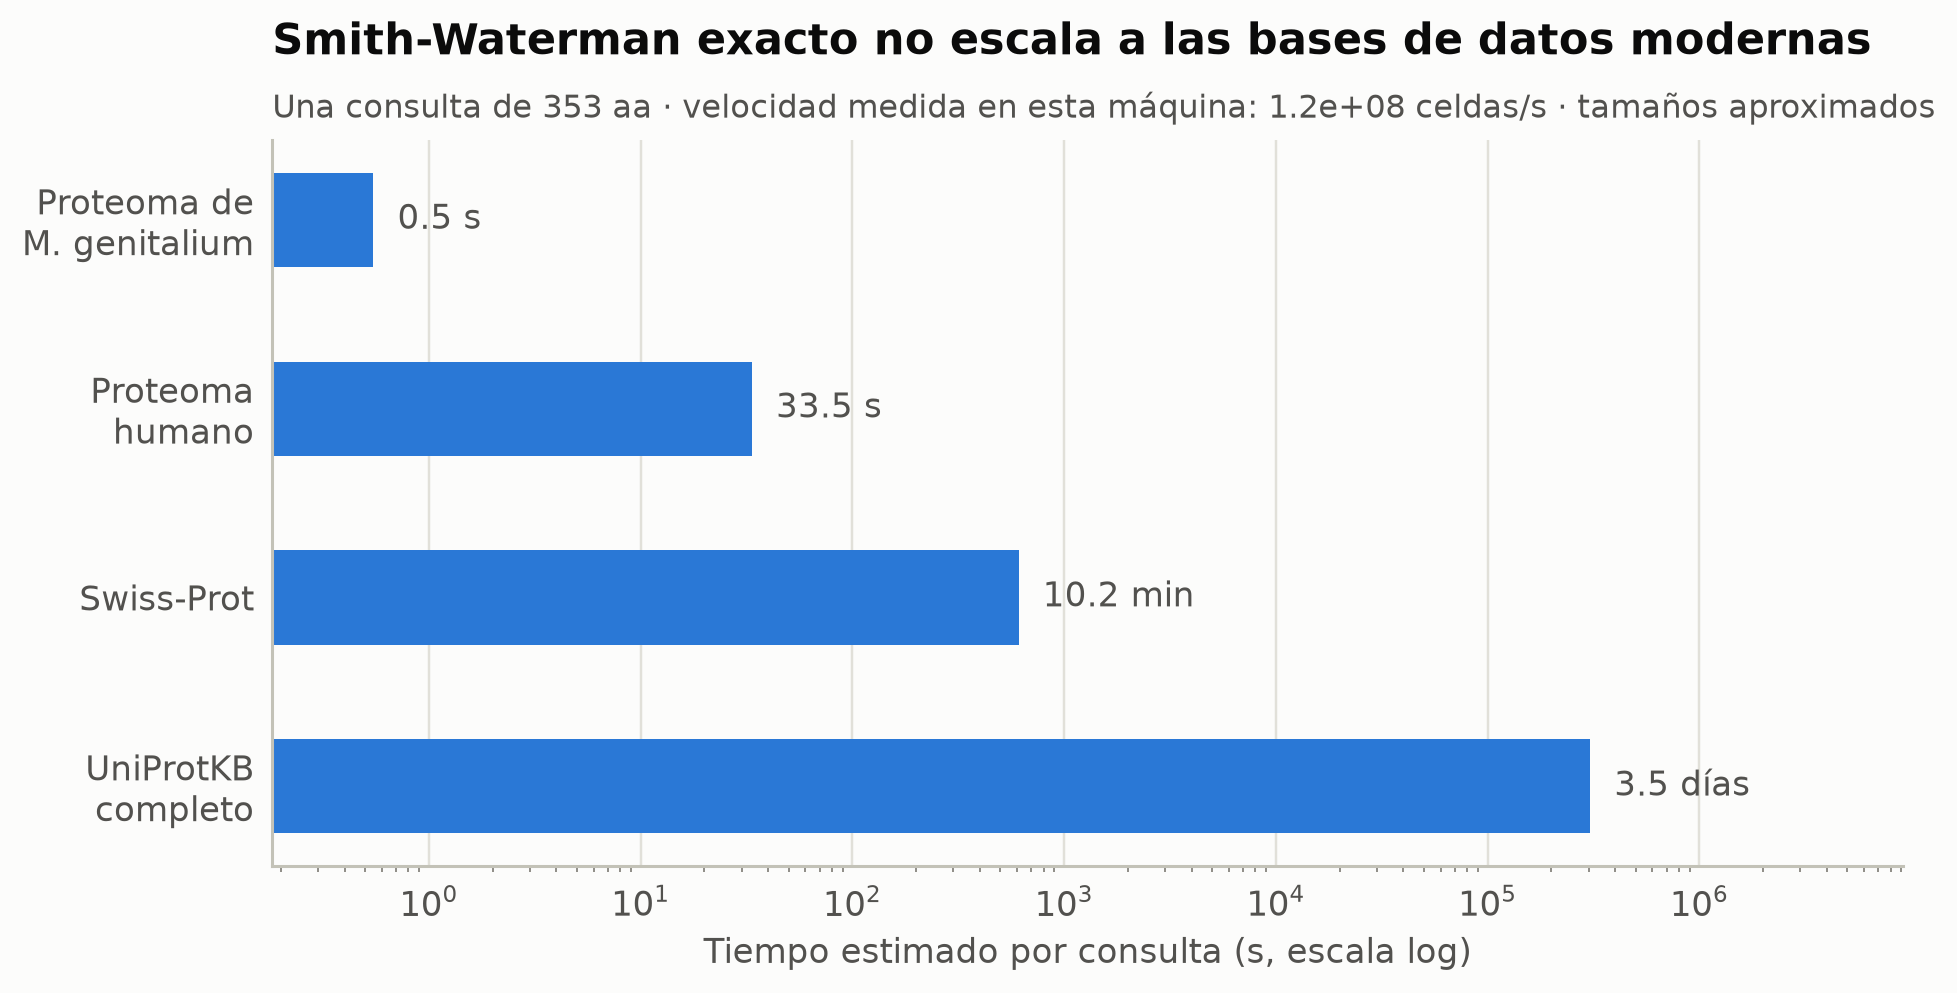

In [3]:
# Proyección del tiempo de Smith-Waterman para bases de datos cada vez más grandes (órdenes de magnitud)
databases = pd.DataFrame({
    "database": ["Proteoma de\nM. genitalium", "Proteoma\nhumano", "Swiss-Prot", "UniProtKB\ncompleto"],
    "residues": [N_DB, 1.1e7, 2.0e8, 1.0e11],
})
databases["seconds"] = len(q) * databases["residues"] / cells_per_s

def human_time(s):
    for unit, size in [("días", 86400), ("horas", 3600), ("min", 60)]:
        if s >= size:
            return f"{s/size:.1f} {unit}"
    return f"{s:.1f} s"

fig, ax = plt.subplots(figsize=(9, 4.4))
bars = ax.barh(databases["database"], databases["seconds"], color=ec.BLUE, height=0.5)
for b, s in zip(bars, databases["seconds"]):
    ax.text(b.get_width() * 1.3, b.get_y() + b.get_height() / 2, human_time(s), va="center", color=ec.INK_2)
ax.set_xscale("log")
ax.set_xlim(databases["seconds"].min() / 3, databases["seconds"].max() * 30)
ax.invert_yaxis()
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("Tiempo estimado por consulta (s, escala log)")
ec.title(ax, "Smith-Waterman exacto no escala a las bases de datos modernas",
         f"Una consulta de {len(q)} aa · velocidad medida en esta máquina: {cells_per_s:.1e} celdas/s · tamaños aproximados")
plt.show()

> 🔎 **Qué observamos.** Contra el pequeño proteoma de *Mycoplasma* la búsqueda exacta es instantánea, pero el tiempo
> crece **en proporción directa** al tamaño de la base de datos. Las bases de datos públicas crecen más rápido que la
> velocidad de las computadoras, así que el problema empeora cada año. En 1990, Altschul, Gish, Miller, Myers y Lipman
> propusieron BLAST: sacrificar una pequeña parte de la sensibilidad a cambio de ir **cientos de veces más rápido**.

## 2. La idea de BLAST: buscar primero palabras parecidas (semillas)

Piense en cómo encuentra una canción de la que sólo recuerda un pedazo de la letra: no escucha todo el catálogo; busca
un par de palabras características y **sólo después** escucha con atención las canciones que las contienen.

BLAST hace lo mismo:

1. Corta la consulta en **palabras** cortas de longitud $w$ (para proteínas, $w = 3$).
2. Para cada palabra fabrica la lista de palabras **vecinas**: todas las palabras de 3 letras que, alineadas con la
   original sin huecos, suman un puntaje BLOSUM62 **mayor o igual a un umbral $T$** (por defecto $T = 11$).
3. Busca esas palabras vecinas en un **índice** de la base de datos (como el índice alfabético al final de un libro).
   Cada coincidencia es un **impacto** o **semilla** (*hit*).

El puntaje de una palabra vecina $u = u_1u_2u_3$ frente a la palabra de la consulta $v = v_1v_2v_3$ es simplemente:

$$
S(v, u) \;=\; \sum_{k=1}^{w} s(v_k, u_k) \qquad\qquad u \in \mathcal{N}_T(v) \iff S(v,u) \ge T
$$

| Símbolo | Significado |
|---|---|
| $w$ | longitud de la palabra (3 en BLASTP) |
| $v_k,\ u_k$ | el $k$-ésimo aminoácido de la palabra de la consulta y de la palabra candidata |
| $s(a, b)$ | el valor de la matriz BLOSUM62 para el par de aminoácidos $a, b$ |
| $\mathcal{N}_T(v)$ | el **vecindario** de $v$: todas las palabras con puntaje $\ge T$ |
| $T$ | umbral: más bajo = más vecinos = más sensible pero más lento |

### Ejemplo a mano: la palabra `PQG`

| Palabra candidata | $s(\text{P},\cdot)$ | $s(\text{Q},\cdot)$ | $s(\text{G},\cdot)$ | Total | ¿Vecina con $T=11$? |
|---|---|---|---|---|---|
| `PQG` | $s(P,P)=7$ | $s(Q,Q)=5$ | $s(G,G)=6$ | **18** | ✔ |
| `PEG` | $7$ | $s(Q,E)=2$ | $6$ | **15** | ✔ |
| `PRG` | $7$ | $s(Q,R)=1$ | $6$ | **14** | ✔ |
| `PQA` | $7$ | $5$ | $s(G,A)=0$ | **12** | ✔ |
| `AQG` | $s(P,A)=-1$ | $5$ | $6$ | **10** | ✘ |

Observe que la propia palabra `PQG` no está garantizada: una palabra con aminoácidos "baratos" en BLOSUM62 podría no
alcanzar $T$ ni siquiera frente a sí misma.

In [4]:
AA = "ARNDCQEGHILKMFPSTWYV"
AA_INDEX = {a: i for i, a in enumerate(AA)}
S = np.array([[blosum62[a][b] for b in AA] for a in AA])        # BLOSUM62 como matriz 20 x 20
W = 3
ALL_WORDS = np.array(np.meshgrid(range(20), range(20), range(20), indexing="ij")).reshape(3, -1).T   # 8000 palabras

@functools.lru_cache(maxsize=None)
def neighborhood(word, T=11):
    """Palabras de 3 letras cuyo puntaje BLOSUM62 frente a `word` es >= T (con sus puntajes)."""
    v = [AA_INDEX[c] for c in word]
    scores = S[v[0], ALL_WORDS[:, 0]] + S[v[1], ALL_WORDS[:, 1]] + S[v[2], ALL_WORDS[:, 2]]
    keep = np.where(scores >= T)[0]
    order = keep[np.argsort(-scores[keep])]
    return tuple("".join(AA[x] for x in ALL_WORDS[k]) for k in order), tuple(int(scores[k]) for k in order)

words, scores = neighborhood("PQG")
print(f"Vecindario de PQG con T = 11: {len(words)} palabras")
print(list(zip(words, scores))[:12], "...")

Vecindario de PQG con T = 11: 21 palabras
[('PQG', 18), ('PEG', 15), ('PRG', 14), ('PKG', 14), ('PSG', 13), ('PNG', 13), ('PDG', 13), ('PMG', 13), ('PHG', 13), ('PTG', 12), ('PAG', 12), ('PPG', 12)] ...


¿Cómo cambia el tamaño del vecindario con $T$? Depende mucho de la palabra, y el resultado sorprende. El triptófano
(`W`) es raro y muy conservado, así que BLOSUM62 le da un puntaje altísimo consigo mismo: $s(W,W) = 11$. Por eso en
`WWW` **basta con que una sola posición coincida** para alcanzar $T = 11$, y la palabra tiene cientos de vecinos. La
leucina, en cambio, es tan común que coincidir en L "vale poco" ($s(L,L) = 4$): `LLL` apenas suma 12 frente a sí
misma y tiene muy pocos vecinos.

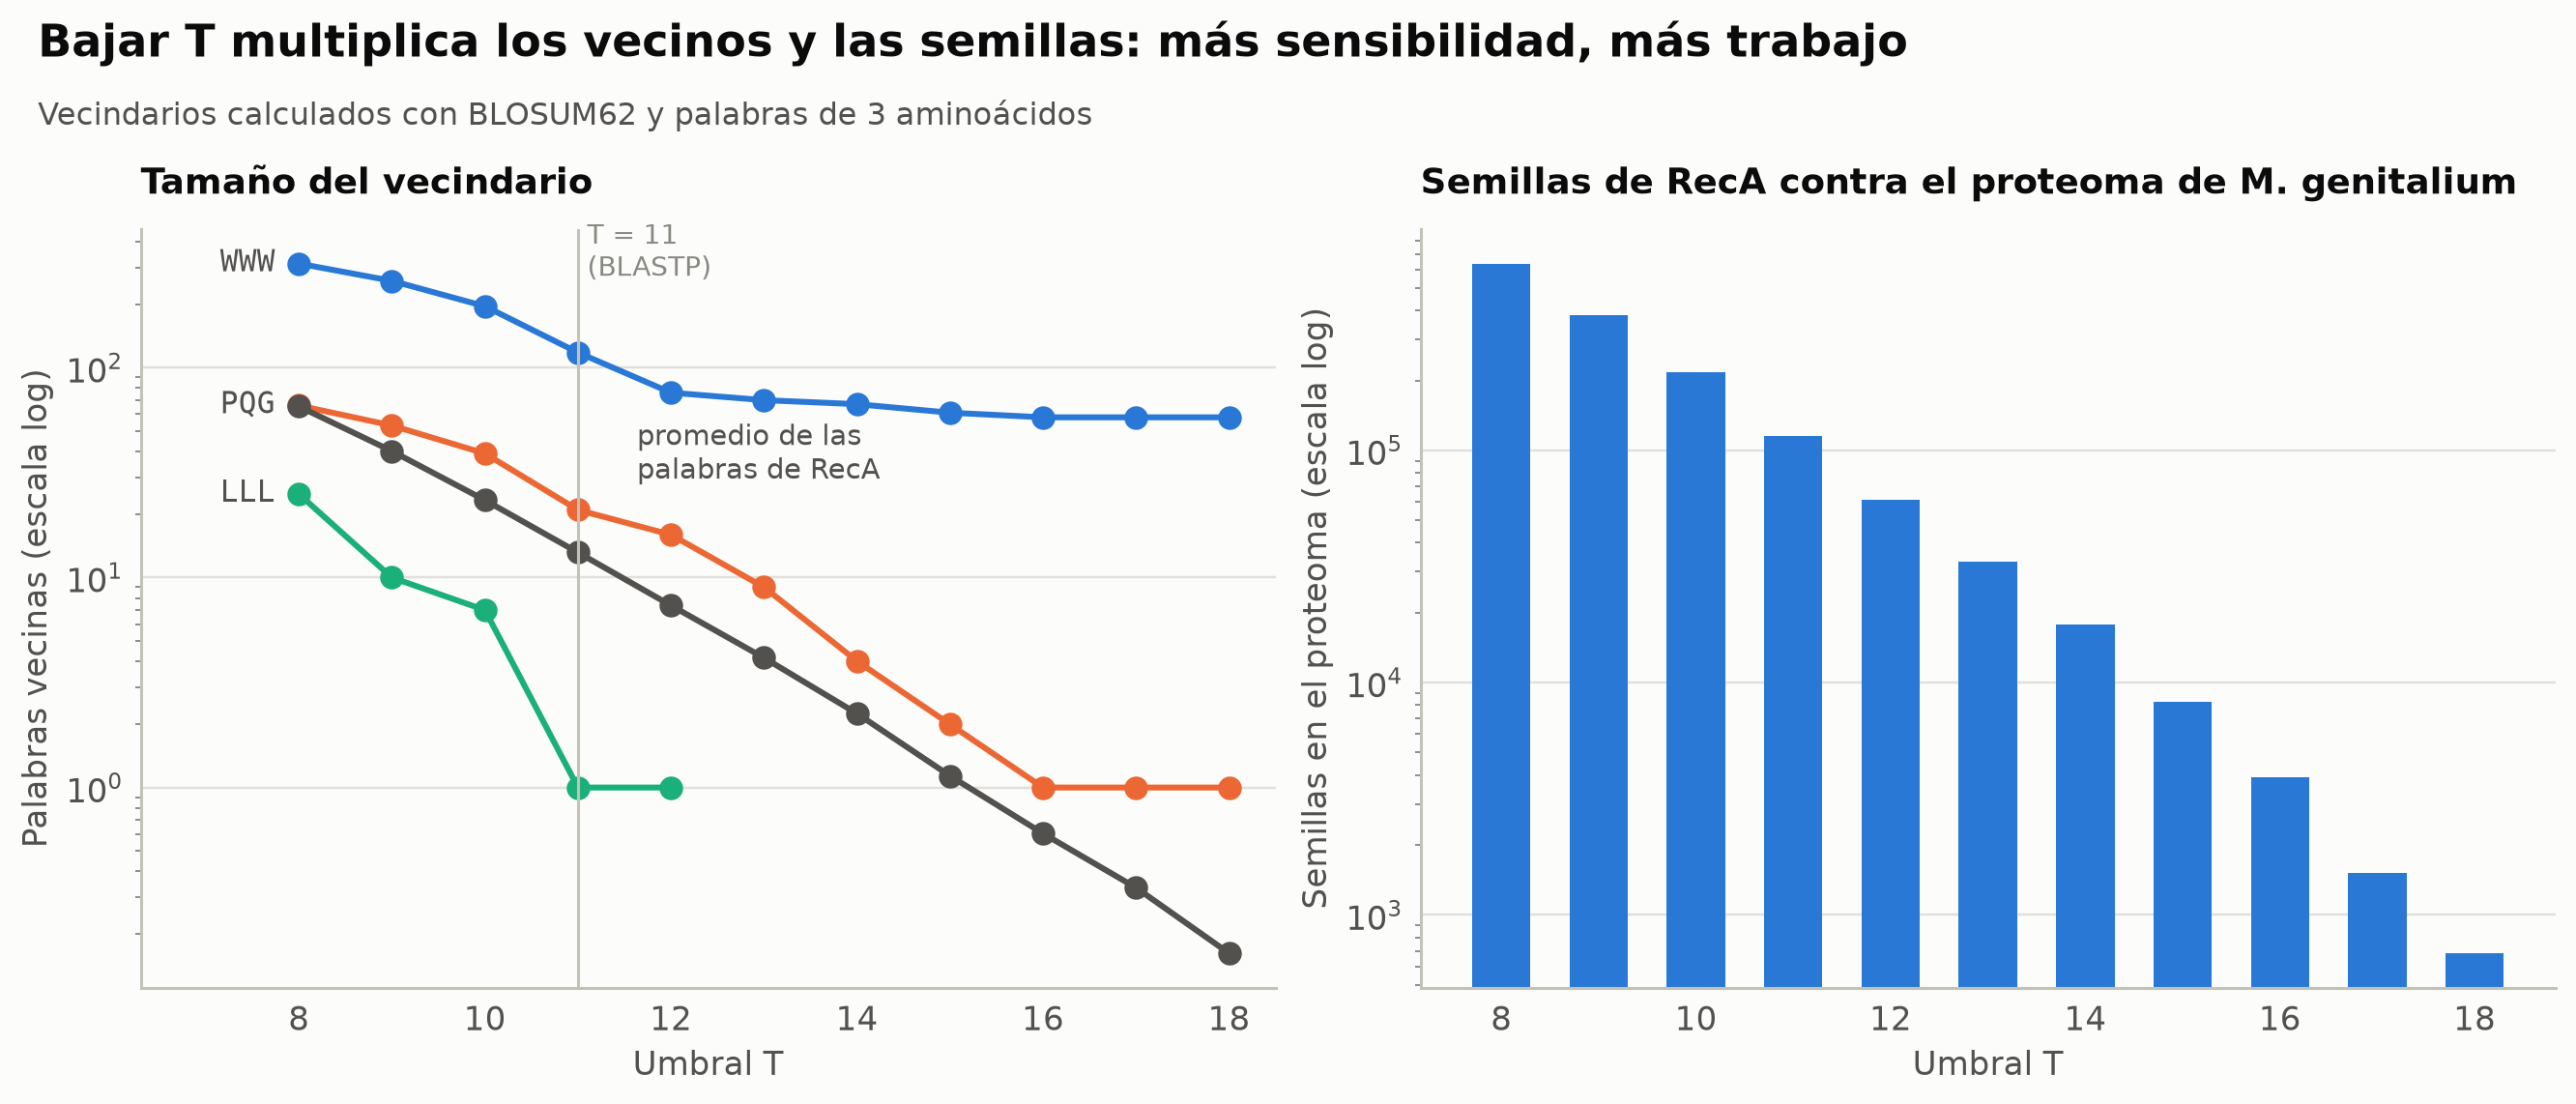

In [5]:
T_values = np.arange(8, 19)
example_words = {"WWW": ec.BLUE, "PQG": ec.ORANGE, "LLL": ec.AQUA}
# Tamaño promedio del vecindario sobre todas las palabras de la proteína RecA de E. coli
reca_words = [queries["RECA"][i:i + 3] for i in range(len(queries["RECA"]) - 2)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ax = axes[0]
for w, c in example_words.items():
    sizes = [len(neighborhood(w, int(T))[0]) or np.nan for T in T_values]   # 0 no existe en escala log
    ax.plot(T_values, sizes, "o-", color=c)
    ax.annotate(w, (T_values[0], sizes[0]), xytext=(-8, 0), textcoords="offset points", ha="right", va="center",
                fontsize=10, color=ec.INK_2, family="DejaVu Sans Mono")
mean_sizes = [np.mean([len(neighborhood(w, int(T))[0]) for w in reca_words]) for T in T_values]
ax.plot(T_values, mean_sizes, "o-", color=ec.INK_2)
ax.annotate("promedio de las\npalabras de RecA", (T_values[3], mean_sizes[3]), xytext=(20, 25),
            textcoords="offset points", fontsize=9.5, color=ec.INK_2,
            arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ax.set_yscale("log"); ax.set_xlabel("Umbral T"); ax.set_ylabel("Palabras vecinas (escala log)")
ax.set_xlim(6.3, 18.5)
ax.axvline(11, color=ec.BASELINE, lw=1); ax.text(11.1, ax.get_ylim()[1] * 0.6, "T = 11\n(BLASTP)", fontsize=9, color=ec.MUTED)
ax.set_title("Tamaño del vecindario", fontsize=12)

# Panel 2: número de semillas que generaría RecA contra el proteoma, según T
db_word_counts = defaultdict(int)
for _, _, seq in proteome:
    for j in range(len(seq) - 2):
        db_word_counts[seq[j:j + 3]] += 1
seeds_per_T = [sum(db_word_counts.get(u, 0) for w in reca_words for u in neighborhood(w, int(T))[0]) for T in T_values]
axes[1].bar(T_values, seeds_per_T, color=ec.BLUE, width=0.6)
axes[1].set_yscale("log"); axes[1].set_xlabel("Umbral T"); axes[1].set_ylabel("Semillas en el proteoma (escala log)")
axes[1].set_title("Semillas de RecA contra el proteoma de M. genitalium", fontsize=12)
axes[1].grid(axis="x", visible=False)
ec.fig_title(fig, "Bajar T multiplica los vecinos y las semillas: más sensibilidad, más trabajo",
             "Vecindarios calculados con BLOSUM62 y palabras de 3 aminoácidos")
plt.show()

> 🔎 **Qué observamos.** Cada punto que baja $T$ multiplica el número de vecinos (la escala es logarítmica). Con
> $T = 11$ la palabra `WWW` tiene más de cien vecinos, `PQG` unos veinte y `LLL` sólo uno (ella misma); por encima
> de $T = 12$, `LLL` ya no genera ninguna semilla. $T$ es el **perilla**
> principal entre velocidad y sensibilidad: el valor 11 se eligió empíricamente como un buen compromiso.

### Explorador interactivo de vecindarios

Elija una palabra en el menú y pase el cursor sobre las barras: verá cómo se reparte el puntaje entre las tres
posiciones.

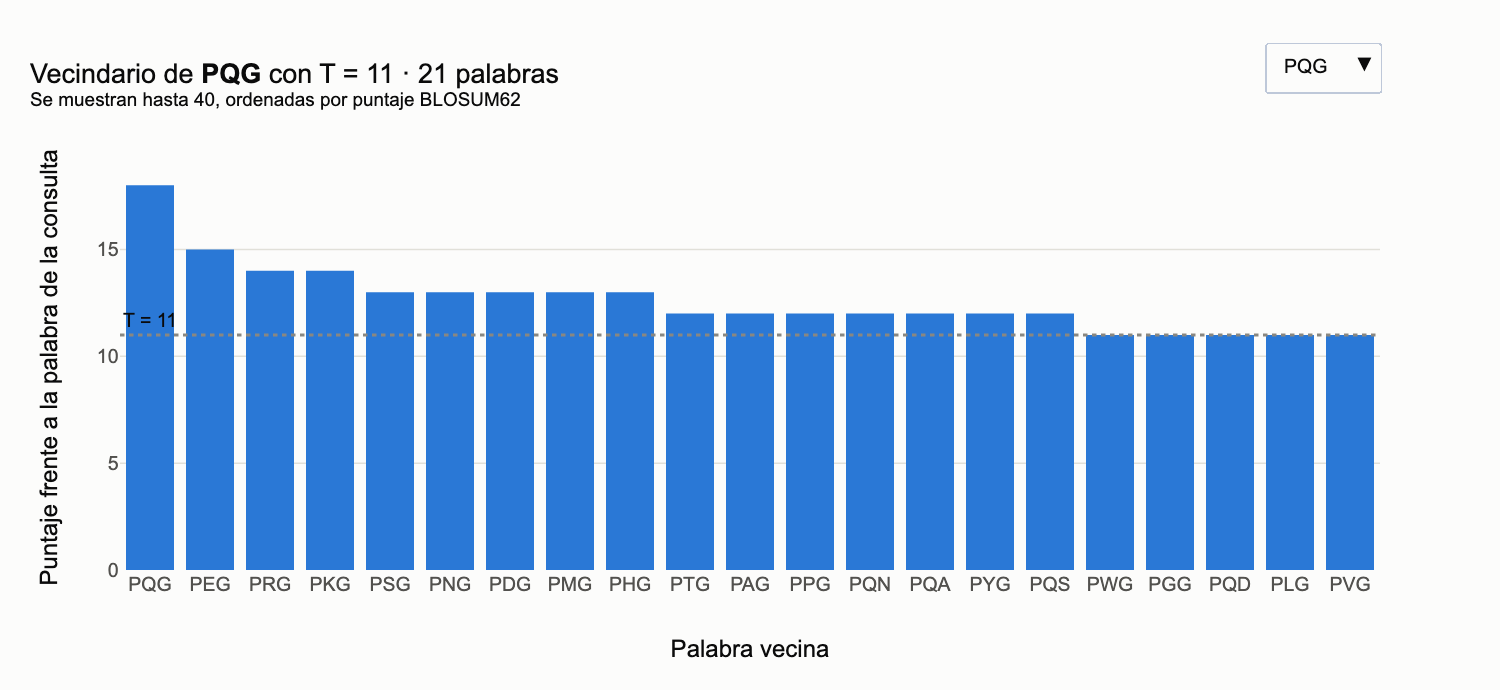

In [6]:
explore_words = ["PQG", "WWW", "LLL", "KNA", "GDS", "CYF"]
fig = go.Figure()
for i, w in enumerate(explore_words):
    nw, ns = neighborhood(w, 11)
    nw, ns = nw[:40], ns[:40]
    parts = [" + ".join(f"s({a},{b})={int(S[AA_INDEX[a], AA_INDEX[b]]):+d}" for a, b in zip(w, u)) for u in nw]
    fig.add_bar(x=list(nw), y=list(ns), visible=(i == 0), marker_color=ec.BLUE, name=w,
                customdata=parts, hovertemplate="<b>%{x}</b> · puntaje %{y}<br>%{customdata}<extra></extra>")
buttons = [dict(label=w, method="update",
                args=[{"visible": [j == i for j in range(len(explore_words))]},
                      {"title.text": f"Vecindario de <b>{w}</b> con T = 11 · {len(neighborhood(w, 11)[0])} palabras"
                                     "<br><sup>Se muestran hasta 40, ordenadas por puntaje BLOSUM62</sup>"}])
           for i, w in enumerate(explore_words)]
fig.update_layout(
    title=dict(text=f"Vecindario de <b>PQG</b> con T = 11 · {len(neighborhood('PQG', 11)[0])} palabras"
                    "<br><sup>Se muestran hasta 40, ordenadas por puntaje BLOSUM62</sup>"),
    updatemenus=[dict(buttons=buttons, x=1.0, xanchor="right", y=1.18, yanchor="bottom")],
    xaxis_title="Palabra vecina", yaxis_title="Puntaje frente a la palabra de la consulta",
    height=460, margin=dict(t=110), showlegend=False)
fig.add_hline(y=11, line_dash="dot", line_color=ec.MUTED, annotation_text="T = 11", annotation_position="top left")
fig.show()

## 3. El método de los dos impactos: pedir una segunda confirmación

Con $T = 11$, una proteína de 350 aminoácidos genera **cientos de miles** de semillas contra una base de datos
modesta. La gran mayoría son coincidencias casuales de tres letras. Extender cada una sería carísimo.

La versión moderna de BLAST (Altschul *et al.*, 1997) añade un filtro muy sencillo: **sólo extiende cuando encuentra
dos semillas en la misma diagonal**, separadas por menos de $A$ posiciones (por defecto $A = 40$). Es como un detector
de humo que sólo dispara la alarma si **dos** sensores cercanos detectan humo: una falsa alarma aislada ya no basta.

¿Qué es "la misma diagonal"? Si una semilla empieza en la posición $i$ de la consulta y $j$ de la base de datos, su
diagonal es:

$$
d \;=\; j - i
$$

Dos semillas en la misma diagonal son compatibles con **un mismo alineamiento sin huecos**. Por ejemplo, semillas en
$(i, j) = (10, 52)$ y $(31, 73)$ tienen ambas $d = 42$ y están separadas por $31 - 10 = 21 < 40$ posiciones: ¡se
extiende! En cambio $(10, 52)$ y $(31, 90)$ tienen diagonales 42 y 59: no se refuerzan.

## 4. Extender sin perder el tiempo: la regla de caída $X$

Una vez aceptada una semilla, BLAST la **extiende** hacia ambos lados, sumando el puntaje BLOSUM62 de cada nuevo par
de aminoácidos. ¿Hasta dónde? Si se detuviera en el primer par negativo, perdería alineamientos que tienen una
pequeña "zona mala" en medio de dos zonas buenas.

La regla es la de un excursionista prudente: *"sigo caminando mientras no haya bajado más de $X$ metros desde el
punto más alto que he alcanzado; si bajo más, regreso a ese punto más alto"*. Formalmente, si $S_k$ es el puntaje
acumulado tras $k$ pasos:

$$
\text{detenerse cuando}\quad \max_{k' \le k} S_{k'} \;-\; S_k \;>\; X
\qquad\qquad
\text{resultado} = \max_{k'} S_{k'}
$$

| Símbolo | Significado |
|---|---|
| $S_k$ | puntaje acumulado después de extender $k$ posiciones |
| $\max_{k' \le k} S_{k'}$ | el mejor puntaje visto hasta ahora (la "cima") |
| $X$ | la caída máxima tolerada (en BLASTP, del orden de 16–20 puntos para la extensión sin huecos) |

### Ejemplo a mano con $X = 10$

| Paso $k$ | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 |
|---|---|---|---|---|---|---|---|---|
| puntaje del par | +5 | +4 | −2 | +6 | −3 | −4 | −1 | −5 |
| $S_k$ | 5 | 9 | 7 | **13** | 10 | 6 | 5 | 0 |
| cima | 5 | 9 | 9 | 13 | 13 | 13 | 13 | 13 |
| caída | 0 | 0 | 2 | 0 | 3 | 7 | 8 | **13 > 10** → alto |

La extensión se detiene en el paso 8 y **devuelve 13**, el puntaje de la cima (paso 4). El −2 del paso 3 no la detuvo:
era una pequeña bajada antes de volver a subir.

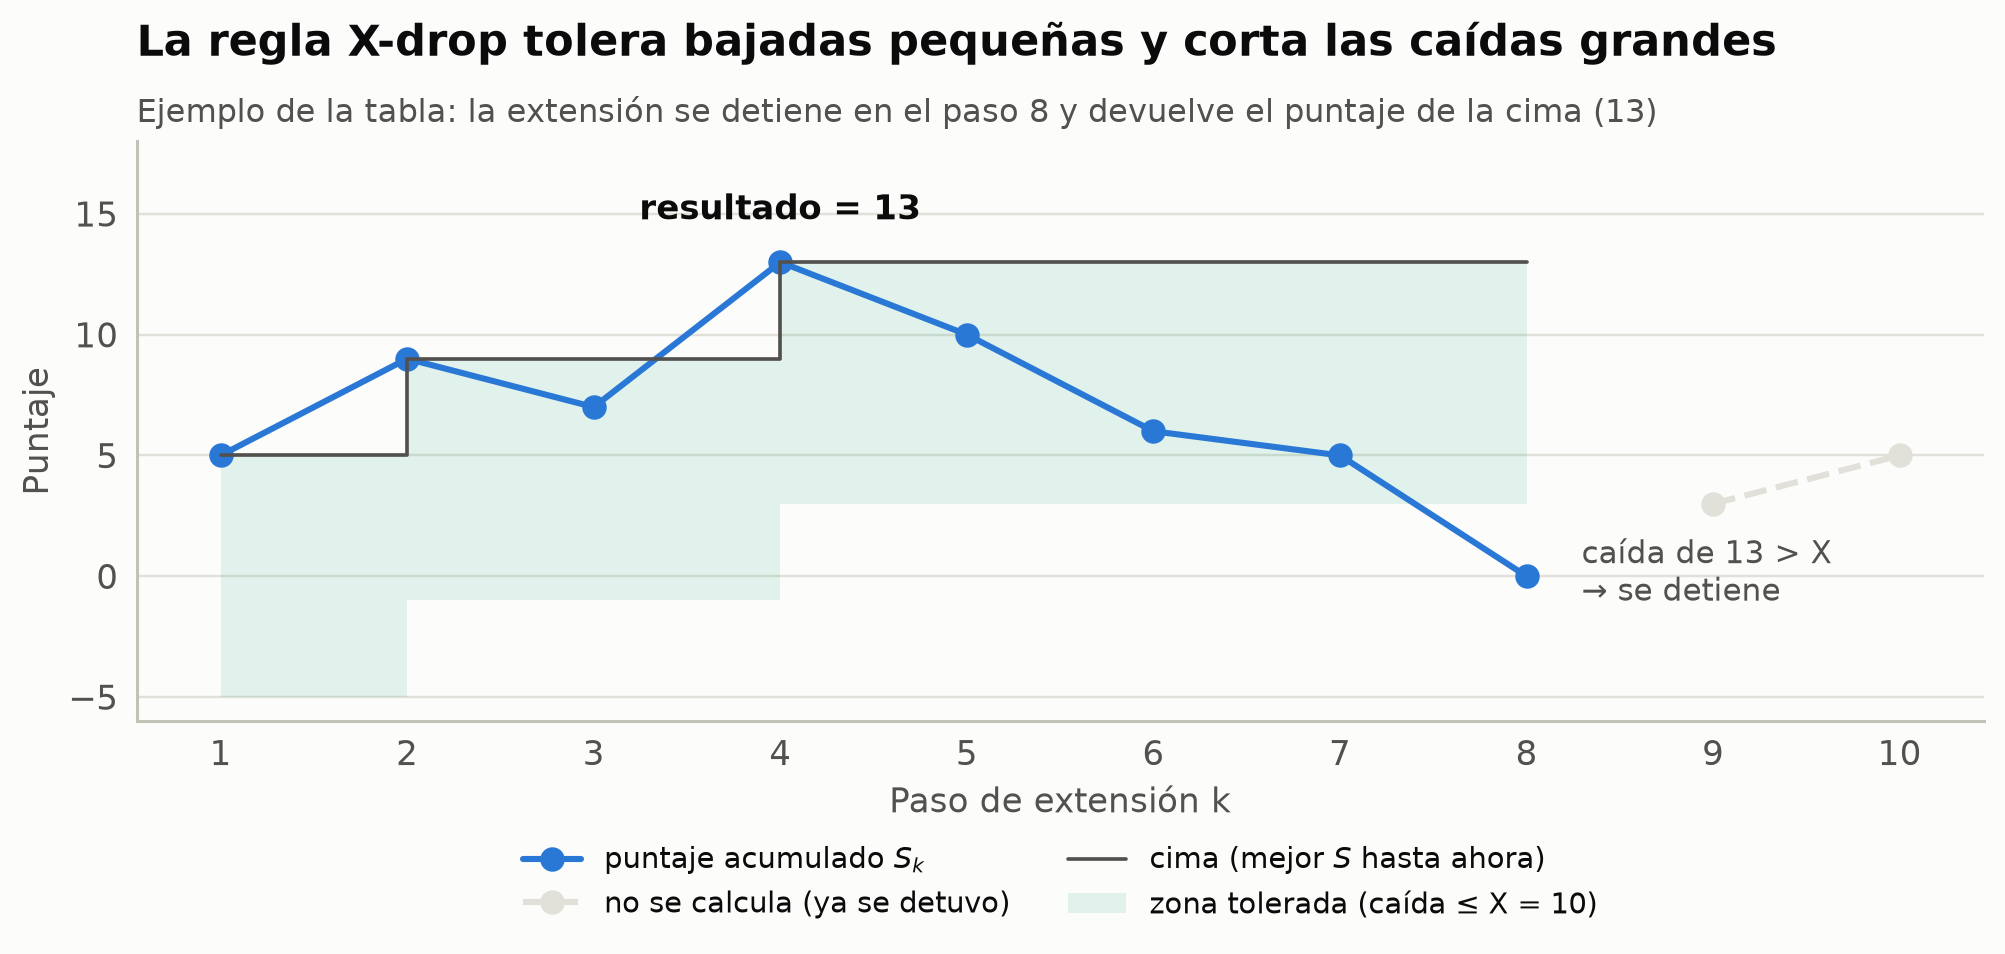

In [7]:
steps = np.array([5, 4, -2, 6, -3, -4, -1, -5, 3, 2])
S_k = np.cumsum(steps)
peak = np.maximum.accumulate(S_k)
X = 10
stop = int(np.argmax(peak - S_k > X))            # primer paso donde la caída supera X

fig, ax = plt.subplots(figsize=(9, 4.2))
k = np.arange(1, len(steps) + 1)
ax.plot(k[:stop + 1], S_k[:stop + 1], "o-", color=ec.BLUE, label="puntaje acumulado $S_k$")
ax.plot(k[stop + 1:], S_k[stop + 1:], "o--", color=ec.GRID, label="no se calcula (ya se detuvo)")
ax.plot(k[:stop + 1], peak[:stop + 1], color=ec.INK_2, lw=1.2, drawstyle="steps-post", label="cima (mejor $S$ hasta ahora)")
ax.fill_between(k[:stop + 1], peak[:stop + 1] - X, peak[:stop + 1], step="post", color=ec.AQUA, alpha=0.12, lw=0,
                label=f"zona tolerada (caída ≤ X = {X})")
best_k = int(np.argmax(S_k[:stop + 1]))
ax.annotate(f"resultado = {S_k[best_k]}", (k[best_k], S_k[best_k]), xytext=(0, 14), textcoords="offset points",
            ha="center", fontweight="bold", color=ec.INK)
ax.annotate("caída de 13 > X\n→ se detiene", (k[stop], S_k[stop]), xytext=(18, -8), textcoords="offset points",
            fontsize=10, color=ec.INK_2)
ax.set_xlabel("Paso de extensión k"); ax.set_ylabel("Puntaje")
ax.set_xticks(k); ax.set_ylim(-6, 18)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2, fontsize=9.5)
ec.title(ax, "La regla X-drop tolera bajadas pequeñas y corta las caídas grandes",
         "Ejemplo de la tabla: la extensión se detiene en el paso 8 y devuelve el puntaje de la cima (13)")
plt.show()

Después de la extensión **sin huecos**, las mejores regiones (llamadas **HSP**, *High-scoring Segment Pairs*) se
refinan con una extensión **con huecos** (una programación dinámica restringida a una banda alrededor de la semilla),
que es lo que permite encontrar inserciones y deleciones. En nuestro mini-BLAST nos quedaremos con la extensión sin
huecos, que ya captura la idea esencial.

✅ **Compruebe su comprensión.** Con $X = 10$ y la sucesión de puntajes +6, +6, −4, −4, −4, +9, ¿dónde se detiene la
extensión y qué puntaje devuelve? (Respuesta: la caída llega a 12 − 0 = 12 > 10 en el paso 5, y devuelve 12; el +9
del paso 6 nunca se ve. Esa es la sensibilidad que se sacrifica.)

## 5. 🎬 Animación: un mini-BLAST en acción

Programemos las tres piezas (vecindario, dos impactos y X-drop) y veámoslas trabajar sobre un ejemplo pequeño:
60 aminoácidos de la proteína RecA de *M. genitalium* frente a una versión "evolucionada" de sí misma (con 35 % de
sustituciones al azar y un pequeño prefijo extra, para que el alineamiento no quede en la diagonal principal).

En la cuadrícula (como un *dot plot*), el eje horizontal es la consulta y el vertical la secuencia de la base de datos:

* **puntos grises**: semillas (palabras vecinas con $T = 11$);
* **puntos azules**: semillas confirmadas por el método de los dos impactos;
* **línea naranja**: la extensión X-drop creciendo desde la semilla elegida; a la derecha, su puntaje acumulado.

In [8]:
def evolve(seq, identity, rng, indel_rate=0.0):
    """Sustituye al azar una fracción (1 - identity) de posiciones; opcionalmente añade indels cortos."""
    freq = np.array([seq.count(a) for a in AA], float) + 1
    freq /= freq.sum()
    out = []
    for c in seq:
        if rng.random() > identity:
            choices = [a for a in AA if a != c]
            p = np.array([freq[AA_INDEX[a]] for a in choices]); p /= p.sum()
            c = rng.choice(choices, p=p)
        out.append(c)
        if indel_rate and rng.random() < indel_rate:
            if rng.random() < 0.5:
                out.append("".join(rng.choice(list(AA), size=rng.integers(1, 4))))   # inserción
            else:
                out.pop()                                                             # deleción
    return "".join(out)

def word_hits(query, subject, T=11):
    """Todas las semillas (i, j): la palabra del sujeto en j es vecina de la palabra de la consulta en i."""
    index = defaultdict(list)
    for j in range(len(subject) - W + 1):
        index[subject[j:j + W]].append(j)
    return [(i, j) for i in range(len(query) - W + 1) for u in neighborhood(query[i:i + W], T)[0] for j in index.get(u, ())]

def two_hit_filter(hits, A=40):
    """Semillas que tienen otra semilla en la misma diagonal a menos de A posiciones."""
    by_diag = defaultdict(list)
    for i, j in hits:
        by_diag[j - i].append((i, j))
    confirmed = []
    for lst in by_diag.values():
        lst.sort()
        for a in range(1, len(lst)):
            if 0 < lst[a][0] - lst[a - 1][0] <= A:
                confirmed.append(lst[a])
    return confirmed

def xdrop_trace(query, subject, i, j, X=16):
    """Extensión sin huecos desde la semilla (i, j); devuelve el mejor HSP y la traza paso a paso."""
    s = lambda a, b: S[AA_INDEX[a], AA_INDEX[b]]
    score = sum(s(query[i + k], subject[j + k]) for k in range(W))
    trace = [(i, j, i + W, j + W, score)]
    best, best_r = score, W
    cur, k = score, W
    while i + k < len(query) and j + k < len(subject):          # hacia la derecha
        cur += s(query[i + k], subject[j + k]); k += 1
        trace.append((i, j, i + k, j + k, cur))
        if cur > best: best, best_r = cur, k
        if best - cur > X: break
    cur, k, best_l = best, 0, 0
    total_best = best
    while i - k - 1 >= 0 and j - k - 1 >= 0:                   # hacia la izquierda (desde la mejor extensión derecha)
        k += 1; cur += s(query[i - k], subject[j - k])
        trace.append((i - k, j - k, i + best_r, j + best_r, cur))
        if cur > total_best: total_best, best_l = cur, k
        if total_best - cur > X: break
    return (total_best, i - best_l, j - best_l, best_r + best_l), trace

rng = np.random.default_rng(34)
mg_reca = next(p[2] for p in proteome if p[1] == "recombinase RecA")
demo_q = mg_reca[40:100]
demo_s = "".join(rng.choice(list(AA), size=8)) + evolve(demo_q, 0.65, rng)
hits = word_hits(demo_q, demo_s)
confirmed = two_hit_filter(hits)
seed = max(confirmed, key=lambda h: sum(S[AA_INDEX[demo_q[h[0] + k]], AA_INDEX[demo_s[h[1] + k]]] for k in range(W)))
hsp, trace = xdrop_trace(demo_q, demo_s, *seed)
print(f"Semillas: {len(hits)} · confirmadas por dos impactos: {len(confirmed)} · HSP: puntaje {hsp[0]}, "
      f"consulta {hsp[1]}–{hsp[1] + hsp[3]}, sujeto {hsp[2]}–{hsp[2] + hsp[3]}")

Semillas: 32 · confirmadas por dos impactos: 25 · HSP: puntaje 168.0, consulta 0–60, sujeto 8–68


![Mini-BLAST: semillas (gris), confirmación por dos impactos (azul) y extensión X-drop (naranja)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-03-alineamiento/3.4_semillas.gif)

*Mini-BLAST: semillas (gris), confirmación por dos impactos (azul) y extensión X-drop (naranja)*

In [9]:
fig, (ax, ax_s) = plt.subplots(1, 2, figsize=(11, 5.2), width_ratios=[1.25, 1])
ax.set_xlim(-1, len(demo_q)); ax.set_ylim(len(demo_s), -1)
ax.set_xlabel("Consulta (posición)"); ax.set_ylabel("Base de datos (posición)")
ax.grid(True, axis="both", color=ec.GRID, lw=0.5)
seed_pts = ax.scatter([], [], s=12, color=ec.MUTED, zorder=2)
conf_pts = ax.scatter([], [], s=34, color=ec.BLUE, edgecolor=ec.SURFACE, linewidth=1, zorder=3)
ext_line, = ax.plot([], [], color=ec.ORANGE, lw=4, solid_capstyle="round", zorder=4)
ax.set_title("Cuadrícula consulta × base de datos", fontsize=12)

scores = [t[4] for t in trace]
ax_s.set_xlim(0, len(trace) + 1); ax_s.set_ylim(min(0, min(scores)) - 5, max(scores) + 12)
ax_s.set_xlabel("Paso de extensión"); ax_s.set_ylabel("Puntaje acumulado")
score_line, = ax_s.plot([], [], color=ec.ORANGE)
peak_line, = ax_s.plot([], [], color=ec.INK_2, lw=1, drawstyle="steps-post")
status = ax_s.text(0.03, 0.95, "", transform=ax_s.transAxes, va="top", fontsize=10, color=ec.INK)
ax_s.set_title("Extensión X-drop (X = 16)", fontsize=12)

n_seed_frames, n_conf_frames = 12, 4
ext_idx = np.unique(np.linspace(1, len(trace), 40).astype(int))
frames = n_seed_frames + n_conf_frames + len(ext_idx)
hits_arr = np.array(hits); conf_arr = np.array(confirmed)

def update(f):
    if f < n_seed_frames:
        k = int(len(hits_arr) * (f + 1) / n_seed_frames)
        seed_pts.set_offsets(np.column_stack([hits_arr[:k, 0], hits_arr[:k, 1]]))
        status.set_text(f"1) Buscando palabras vecinas… {k} semillas")
    elif f < n_seed_frames + n_conf_frames:
        conf_pts.set_offsets(np.column_stack([conf_arr[:, 0], conf_arr[:, 1]]))
        status.set_text(f"2) Dos impactos en la misma diagonal:\n    {len(confirmed)} semillas confirmadas")
    else:
        n = ext_idx[f - n_seed_frames - n_conf_frames]
        qs, ss, qe, se, _ = trace[n - 1]
        ext_line.set_data([qs, qe - 1], [ss, se - 1])
        sc = scores[:n]
        score_line.set_data(np.arange(1, n + 1), sc)
        peak_line.set_data(np.arange(1, n + 1), np.maximum.accumulate(sc))
        done = n == len(trace)
        status.set_text(f"3) Extendiendo… puntaje {sc[-1]}, cima {max(sc)}" +
                        (f"\n    ¡Caída > X! HSP final = {hsp[0]}" if done else ""))
    return seed_pts, conf_pts, ext_line, score_line, peak_line, status

ec.animate(fig, update, frames=frames, interval=140, name="3.4_semillas")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Las semillas grises están regadas por toda la cuadrícula: la mayoría son ruido. Las
> confirmadas por dos impactos (azules) se concentran en **una diagonal**, desplazada 8 posiciones por el prefijo que
> añadimos: esa es la señal de homología. La extensión recorre la diagonal, tolera algunas bajadas del puntaje y se
> detiene cuando la caída supera $X$.

## 6. 🧪 Experimento: nuestro mini-BLAST contra el proteoma de *M. genitalium*

Ahora armamos el programa completo: un **índice** de todas las palabras del proteoma (504 proteínas, unos 180 000
aminoácidos) y la búsqueda de cada una de las cinco proteínas de *E. coli*.

*E. coli* y *M. genitalium* están separadas por miles de millones de años de evolución, pero conservan proteínas
esenciales: la recombinasa RecA, el factor de elongación EF-Tu, las chaperonas DnaK y GroEL y la girasa GyrB.

> 🤔 **Antes de ejecutar, prediga:** ¿encontrará el mini-BLAST la proteína correcta para las cinco consultas? ¿Cuál
> cree que será la más conservada?

In [10]:
def build_index(db):
    """Índice palabra → lista de (proteína, posición). Es el 'índice alfabético' de la base de datos."""
    index = defaultdict(list)
    for sid, (_, _, seq) in enumerate(db):
        for j in range(len(seq) - W + 1):
            index[seq[j:j + W]].append((sid, j))
    return index

def mini_blast(query, db, index, T=11, A=40, X=16):
    """BLAST simplificado: vecindario (T) → dos impactos (A) → extensión sin huecos (X). Un HSP por proteína."""
    by_diag = defaultdict(list)
    n_hits = 0
    for i in range(len(query) - W + 1):
        for u in neighborhood(query[i:i + W], T)[0]:
            for sid, j in index.get(u, ()):
                by_diag[(sid, j - i)].append((i, j)); n_hits += 1
    best, n_ext = {}, 0
    for (sid, d), lst in by_diag.items():
        lst.sort(); covered_until = -1
        for a in range(1, len(lst)):
            (i1, _), (i2, j2) = lst[a - 1], lst[a]
            if 0 < i2 - i1 <= A and i2 > covered_until:
                (score, qs, ss, length), _ = xdrop_trace(query, db[sid][2], i2, j2, X)
                n_ext += 1; covered_until = qs + length
                if score > best.get(sid, (0,))[0]:
                    best[sid] = (score, qs, ss, length)
    return best, {"semillas": n_hits, "extensiones": n_ext, "proteínas con HSP": len(best)}

index = build_index(proteome)
rows, funnel = [], {}
t0 = time.perf_counter()
for name, seq in queries.items():
    hsps, counts = mini_blast(seq, proteome, index)
    funnel[name] = counts
    for sid, (score, qs, ss, length) in hsps.items():
        rows.append({"query": name, "subject": proteome[sid][0], "product": proteome[sid][1],
                     "raw_score": score, "q_start": qs + 1, "s_start": ss + 1, "length": length})
hits_df = pd.DataFrame(rows)
print(f"Búsqueda completa en {time.perf_counter() - t0:.1f} s")
(hits_df.sort_values("raw_score", ascending=False).groupby("query").head(2)
        .sort_values(["query", "raw_score"], ascending=[True, False]).reset_index(drop=True))

Búsqueda completa en 9.6 s


,query,subject,product,raw_score,q_start,s_start,length
0,CH60,MG_RS02385,chaperonin GroEL,594.0,152,150,286
1,CH60,MG_RS00950,30S ribosomal protein S5,57.0,405,146,50
2,DNAK,MG_RS01830,molecular chaperone DnaK,612.0,358,339,191
3,DNAK,MG_RS00180,aspartate--tRNA ligase,58.0,347,468,49
4,EFTU1,MG_RS02660,elongation factor Tu,1462.0,1,1,393
5,EFTU1,MG_RS00495,elongation factor G,96.0,50,50,83
6,GYRB,MG_RS00015,DNA topoisomerase (ATP-hydrolyzing) subunit B,579.0,250,267,232
7,GYRB,MG_RS01150,DNA topoisomerase IV subunit B,360.0,32,31,117
8,RECA,MG_RS02065,recombinase RecA,557.0,34,34,204
9,RECA,MG_RS01820,ABC transporter ATP-binding protein,51.0,54,94,27


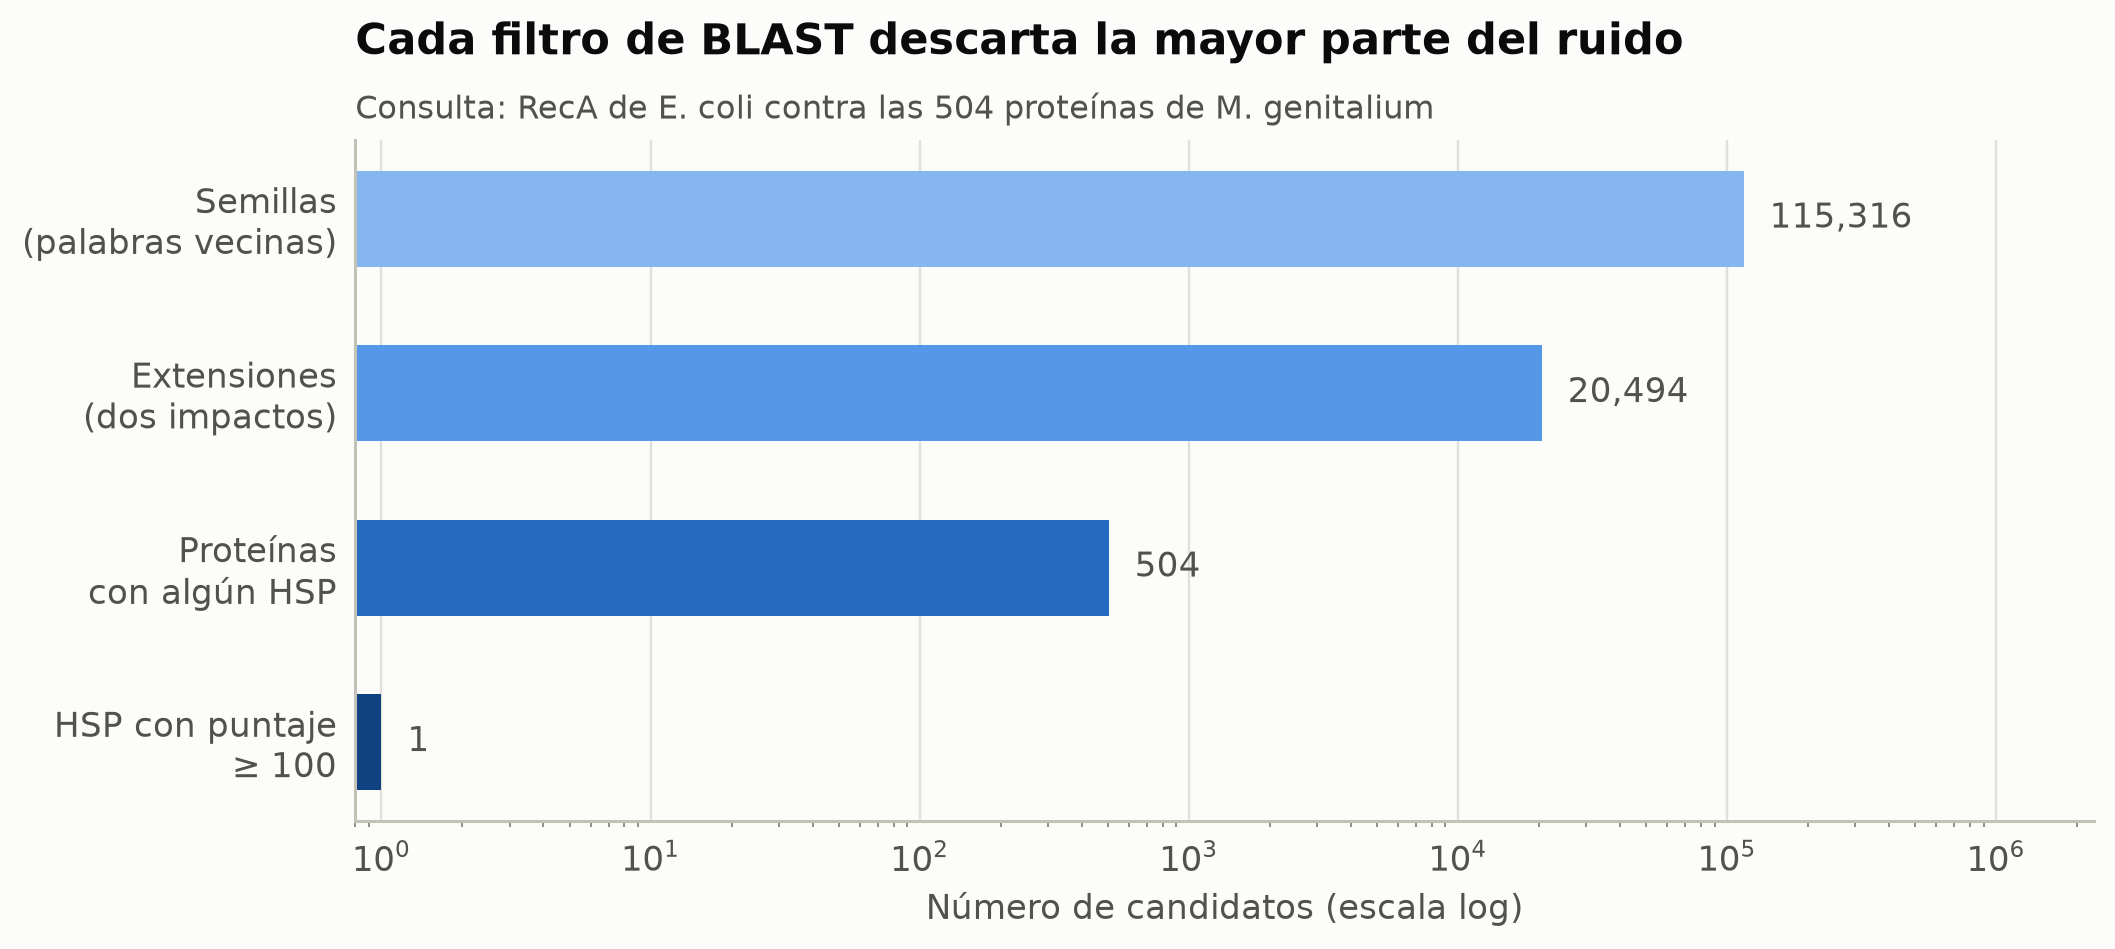

In [11]:
# El embudo de BLAST: cuántos candidatos sobreviven a cada filtro (consulta RecA)
counts = funnel["RECA"]
reca_hsps = hits_df[hits_df["query"] == "RECA"]
stages = {"Semillas\n(palabras vecinas)": counts["semillas"],
          "Extensiones\n(dos impactos)": counts["extensiones"],
          "Proteínas\ncon algún HSP": counts["proteínas con HSP"],
          "HSP con puntaje\n≥ 100": int((reca_hsps["raw_score"] >= 100).sum())}
fig, ax = plt.subplots(figsize=(9.5, 4.2))
bars = ax.barh(list(stages), list(stages.values()), color=[ec.SEQ_BLUE[k] for k in (3, 5, 8, 11)], height=0.55)
for b, v in zip(bars, stages.values()):
    ax.text(b.get_width() * 1.25, b.get_y() + b.get_height() / 2, f"{v:,}", va="center", color=ec.INK_2)
ax.set_xscale("log"); ax.invert_yaxis(); ax.set_xlim(0.8, max(stages.values()) * 20)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("Número de candidatos (escala log)")
ec.title(ax, "Cada filtro de BLAST descarta la mayor parte del ruido",
         "Consulta: RecA de E. coli contra las 504 proteínas de M. genitalium")
plt.show()

> 🔎 **Qué observamos.** Para cada consulta, el mejor resultado es la proteína ortóloga correcta, con un puntaje muy
> por encima del segundo lugar. El embudo muestra por qué BLAST es rápido: de cientos de miles de semillas sólo una
> fracción se extiende, y casi ninguna llega a un puntaje alto.
>
> Pero surge una pregunta incómoda: el segundo lugar de RecA tiene un puntaje de unos 50. ¿Es **eso** una homología
> débil o puro azar? Para responder necesitamos saber qué puntajes produce el azar.

## 7. ¿Es mucho un puntaje de 557? La estadística de los máximos

Cuando alineamos localmente dos secuencias **no relacionadas**, el algoritmo busca el **mejor** tramo entre todos los
posibles. El puntaje resultante es el **máximo** de muchísimos puntajes pequeños. Y los máximos no se comportan como
los promedios.

Piense en la estatura: el promedio de estatura de un salón y el de un estadio son casi iguales, pero **la persona más
alta** del estadio es claramente más alta que la del salón, y la diferencia crece lentamente (logarítmicamente) con el
número de personas. Los promedios siguen la curva normal; los **máximos** siguen una **distribución de valores
extremos**, también llamada de **Gumbel**.

Karlin y Altschul (1990) demostraron que, para alineamientos locales **sin huecos** entre secuencias aleatorias de
longitudes $m$ y $n$, el número esperado de segmentos con puntaje $\ge S$ es:

$$
E \;=\; K\, m\, n\, e^{-\lambda S}
$$

y que la probabilidad de que el mejor puntaje supere $x$ es la cola de una Gumbel:

$$
P(S_{\max} \ge x) \;\approx\; 1 - \exp\!\left(-K\,m\,n\,e^{-\lambda x}\right)
$$

| Símbolo | Significado |
|---|---|
| $S$, $x$ | puntaje bruto del alineamiento (suma de valores BLOSUM62) |
| $m$, $n$ | longitudes de la consulta y de la base de datos (en aminoácidos) |
| $\lambda$ | escala: convierte "puntos BLOSUM" en unidades naturales; dice qué tan rápido cae la cola |
| $K$ | constante que corrige porque los segmentos buenos no son independientes (se solapan) |
| $E$ | número esperado de alineamientos al azar con puntaje $\ge S$ |

### ¿De dónde sale $\lambda$?

Para alineamientos sin huecos, $\lambda$ es la única solución positiva de:

$$
\sum_{a}\sum_{b} p_a\, p_b\, e^{\lambda\, s(a,b)} \;=\; 1
$$

| Símbolo | Significado |
|---|---|
| $p_a,\ p_b$ | frecuencias de fondo de los aminoácidos $a$ y $b$ |
| $s(a,b)$ | valor de la matriz de sustitución |

La ecuación sólo tiene solución si el **puntaje esperado** de un par al azar, $\sum p_a p_b\, s(a,b)$, es
**negativo**: de lo contrario, alinear basura daría puntajes cada vez más altos y ningún alineamiento sería "local".

### Ejemplo a mano: ADN con +1 / −1

Con cuatro bases equiprobables, un par coincide con probabilidad $1/4$ (puntaje $+1$) y difiere con probabilidad
$3/4$ (puntaje $-1$). La ecuación queda:

$$
\tfrac14 e^{\lambda} + \tfrac34 e^{-\lambda} = 1
\;\;\xrightarrow{\;y = e^{\lambda}\;}\;\;
y^2 - 4y + 3 = 0
\;\;\Longrightarrow\;\; y = 3 \;\;\Longrightarrow\;\; \lambda = \ln 3 \approx 1.099
$$

(La otra raíz, $y = 1$, da $\lambda = 0$, que siempre es solución trivial.) Verifiquémoslo y calculemos $\lambda$ para
BLOSUM62 con la composición real del proteoma de *M. genitalium*.

In [12]:
def solve_lambda(freq_a, freq_b, M):
    """Raíz positiva de sum_ab p_a p_b exp(lambda * s_ab) = 1 (Karlin & Altschul, 1990)."""
    f = lambda lam: (np.outer(freq_a, freq_b) * np.exp(lam * M)).sum() - 1
    return optimize.brentq(f, 1e-6, 10)

# ADN +1/-1: esperamos ln(3)
dna_M = np.where(np.eye(4) == 1, 1, -1)
print(f"ADN +1/-1: lambda = {solve_lambda(np.full(4, .25), np.full(4, .25), dna_M):.4f}   (ln 3 = {np.log(3):.4f})")

all_residues = "".join(p[2] for p in proteome)
bg = np.array([all_residues.count(a) for a in AA], float); bg /= bg.sum()
expected_pair = bg @ S @ bg
lambda_theory = solve_lambda(bg, bg, S)
print(f"BLOSUM62, composición de M. genitalium: puntaje esperado por par = {expected_pair:.3f} (negativo ✔)")
print(f"lambda teórico (sin huecos) = {lambda_theory:.4f}")

ADN +1/-1: lambda = 1.0986   (ln 3 = 1.0986)
BLOSUM62, composición de M. genitalium: puntaje esperado por par = -0.882 (negativo ✔)
lambda teórico (sin huecos) = 0.2936


## 8. 🧪 Experimento: la distribución de Gumbel aparece sola

Vamos a fabricar el azar: 3 000 pares de proteínas **aleatorias** de 150 aminoácidos (con la composición del proteoma),
calcular el mejor puntaje local **sin huecos** de cada par y mirar su distribución.

Para que sea rápido, calculamos los 3 000 alineamientos **a la vez** con `numpy`: la recurrencia de Smith-Waterman sin
huecos es $H_{i,j} = \max(0,\ H_{i-1,j-1} + s(q_i, d_j))$, y podemos avanzar fila por fila para todos los pares
simultáneamente.

> 🤔 **Antes de ejecutar, prediga:** ¿será la distribución simétrica como una campana, o tendrá una cola más larga
> hacia un lado? ¿Hacia cuál?

In [13]:
def random_ungapped_scores(n_pairs, length, freq, rng):
    """Mejor puntaje local SIN huecos para n_pairs pares de secuencias aleatorias (vectorizado)."""
    q = rng.choice(20, size=(n_pairs, length), p=freq)
    d = rng.choice(20, size=(n_pairs, length), p=freq)
    H = np.zeros((n_pairs, length + 1)); best = np.zeros(n_pairs)
    for i in range(length):
        row = S[q[:, i][:, None], d]                         # puntajes de la fila i para todos los pares
        H_new = np.zeros_like(H)
        H_new[:, 1:] = np.maximum(0, H[:, :-1] + row)       # diagonal anterior + par actual, nunca < 0
        H = H_new
        best = np.maximum(best, H.max(axis=1))
    return best

rng = np.random.default_rng(2024)
L_RAND = 150
null_scores = random_ungapped_scores(3000, L_RAND, bg, rng)

mu_g, beta_g = stats.gumbel_r.fit(null_scores)
lambda_emp = 1 / beta_g
K_emp = np.exp(lambda_emp * mu_g) / (L_RAND * L_RAND)
mu_n, sd_n = null_scores.mean(), null_scores.std()
print(f"Puntaje medio al azar = {mu_n:.1f} ± {sd_n:.1f}")
print(f"Ajuste Gumbel: lambda = {lambda_emp:.3f} (teoría {lambda_theory:.3f}) · K = {K_emp:.3f}")

Puntaje medio al azar = 27.7 ± 4.2
Ajuste Gumbel: lambda = 0.304 (teoría 0.294) · K = 0.113


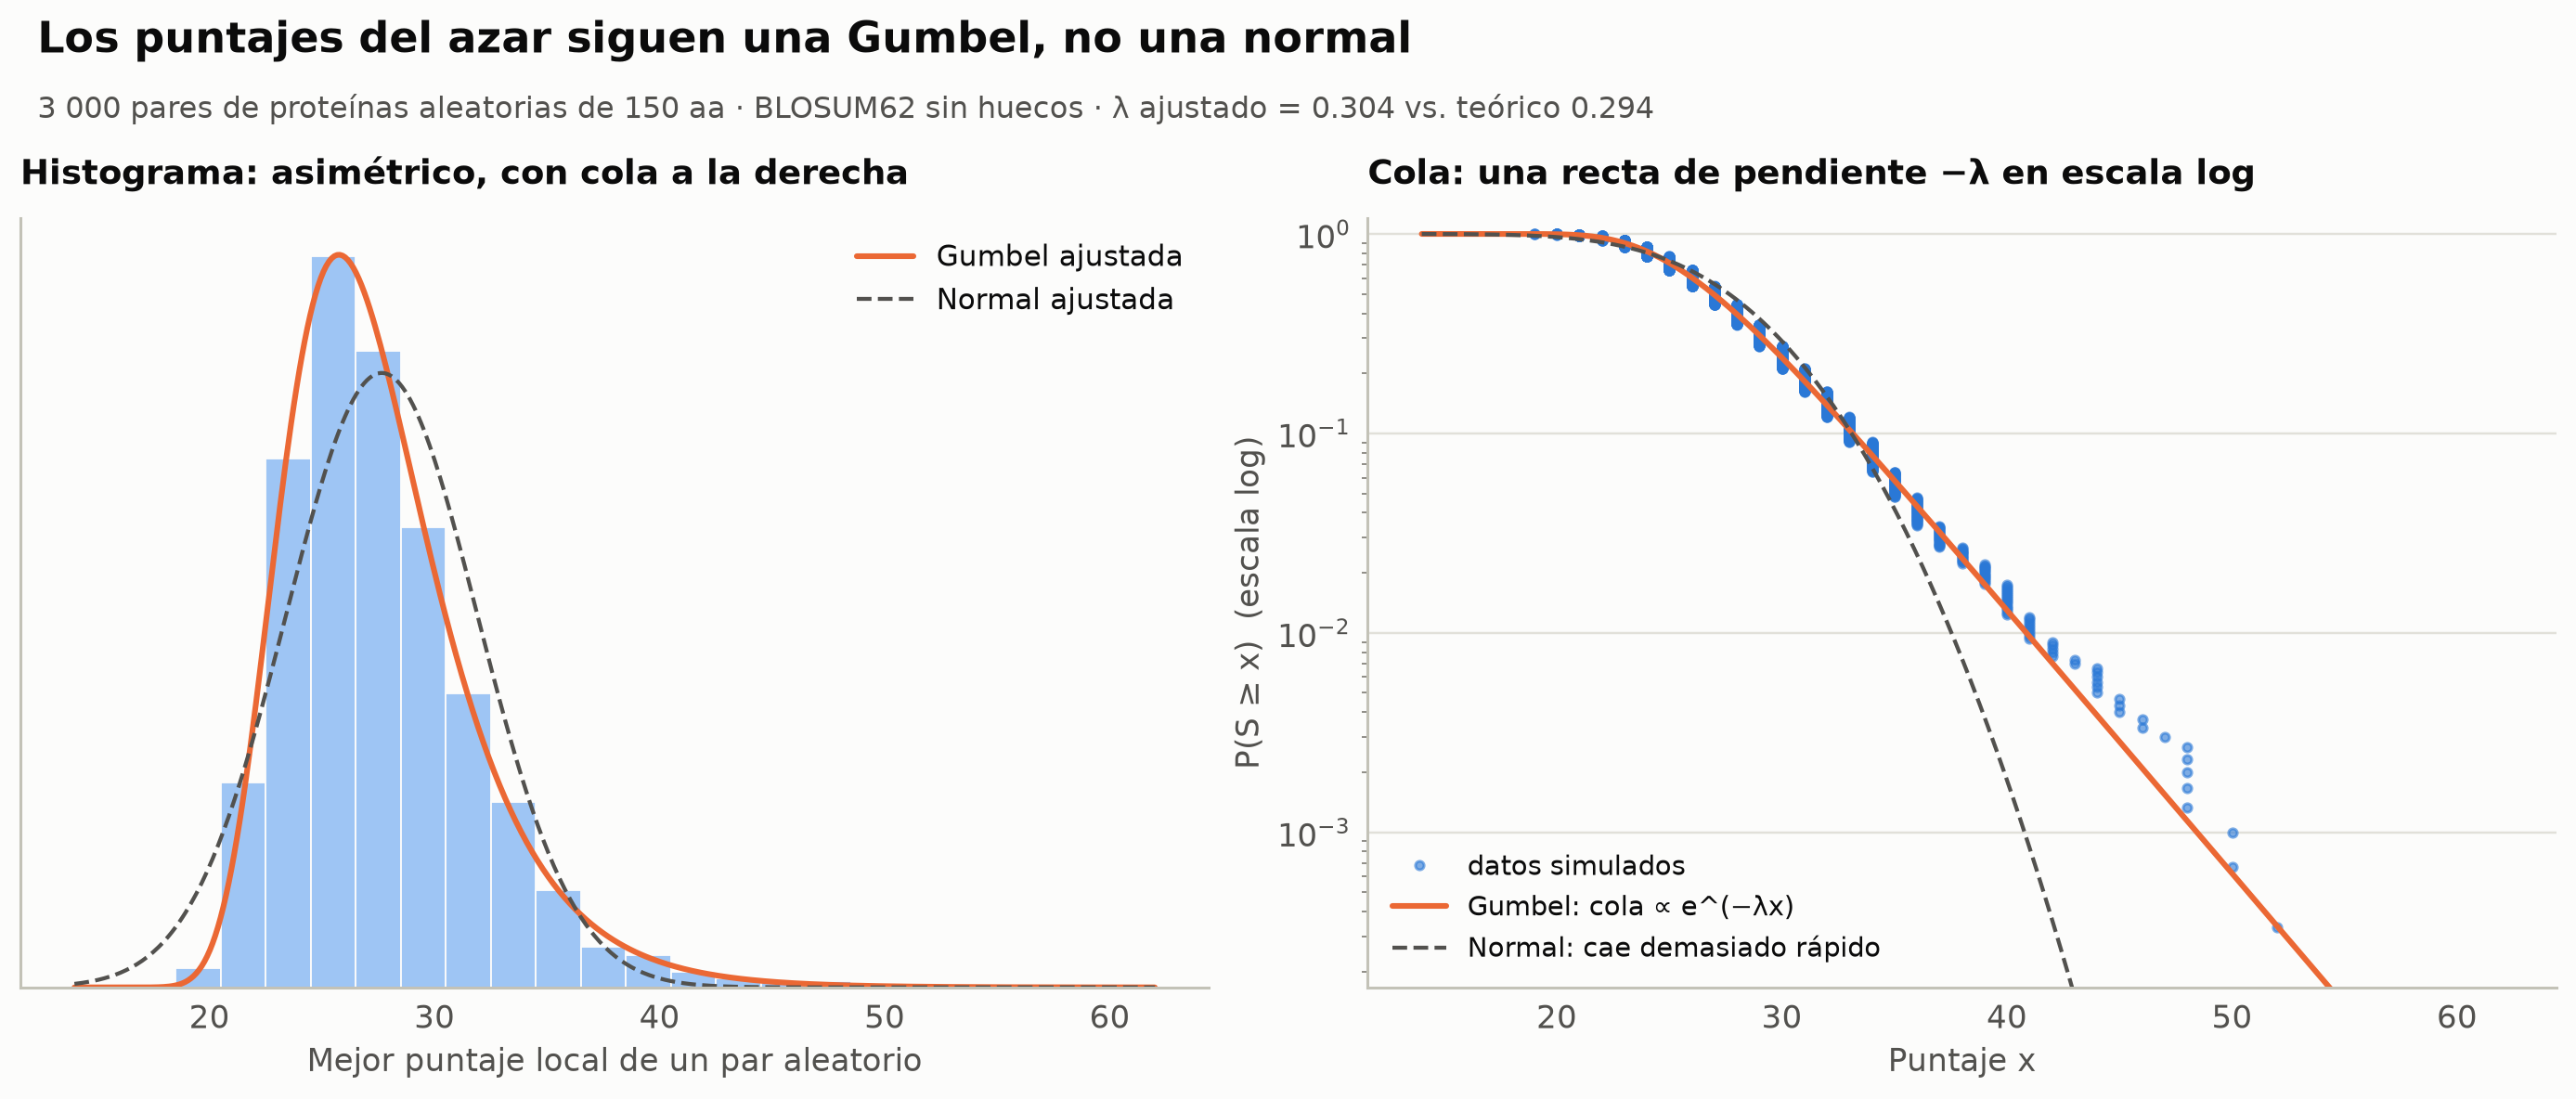

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
bins = np.arange(null_scores.min() - 0.5, null_scores.max() + 1.5, 2)
ax.hist(null_scores, bins=bins, density=True, color=ec.SEQ_BLUE[2], edgecolor=ec.SURFACE, linewidth=0.6)
x = np.linspace(null_scores.min() - 5, null_scores.max() + 10, 400)
ax.plot(x, stats.gumbel_r.pdf(x, mu_g, beta_g), color=ec.ORANGE, label="Gumbel ajustada")
ax.plot(x, stats.norm.pdf(x, mu_n, sd_n), color=ec.INK_2, lw=1.4, ls="--", label="Normal ajustada")
ax.set_xlabel("Mejor puntaje local de un par aleatorio"); ax.set_yticks([])
ax.legend(loc="upper right"); ax.grid(False)
ax.set_title("Histograma: asimétrico, con cola a la derecha", fontsize=12)

ax = axes[1]
xs = np.sort(null_scores)
surv = 1 - np.arange(len(xs)) / len(xs)
ax.semilogy(xs, surv, "o", ms=3, color=ec.BLUE, alpha=0.6, label="datos simulados")
ax.semilogy(x, stats.gumbel_r.sf(x, mu_g, beta_g), color=ec.ORANGE, label="Gumbel: cola ∝ e^(−λx)")
ax.semilogy(x, stats.norm.sf(x, mu_n, sd_n), color=ec.INK_2, lw=1.4, ls="--", label="Normal: cae demasiado rápido")
ax.set_ylim(1 / len(xs) / 2, 1.2)
ax.set_xlabel("Puntaje x"); ax.set_ylabel("P(S ≥ x)  (escala log)")
ax.legend(loc="lower left", fontsize=9.5)
ax.set_title("Cola: una recta de pendiente −λ en escala log", fontsize=12)
ec.fig_title(fig, "Los puntajes del azar siguen una Gumbel, no una normal",
             f"3 000 pares de proteínas aleatorias de {L_RAND} aa · BLOSUM62 sin huecos · "
             f"λ ajustado = {lambda_emp:.3f} vs. teórico {lambda_theory:.3f}")
plt.show()

> 🔎 **Qué observamos.** La distribución tiene una **cola larga hacia la derecha**. En la escala logarítmica (panel
> derecho) la cola de la Gumbel es una **recta** cuya pendiente es $-\lambda$, y los datos simulados la siguen. La
> normal, en cambio, se desploma: si usáramos la normal, diríamos que un puntaje de 50 es casi imposible por azar
> cuando en realidad ocurre con cierta frecuencia. **Usar la distribución equivocada fabrica falsos positivos.**
>
> Además, el $\lambda$ ajustado a la simulación coincide con el calculado con la fórmula de Karlin-Altschul: la teoría
> predice el experimento.

### 🎬 La Gumbel se construye pareja por pareja

![El histograma de puntajes aleatorios se llena y converge a la curva de Gumbel](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-03-alineamiento/3.4_gumbel.gif)

*El histograma de puntajes aleatorios se llena y converge a la curva de Gumbel*

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.set_xlim(bins[0], bins[-1]); ax.set_yticks([]); ax.grid(False)
ymax = stats.gumbel_r.pdf(mu_g, mu_g, beta_g) * 1.35
ax.set_ylim(0, ymax)
ax.plot(x, stats.gumbel_r.pdf(x, mu_g, beta_g), color=ec.ORANGE, lw=2, zorder=3)
ax.set_xlabel("Mejor puntaje local de un par aleatorio")
counter = ax.text(0.98, 0.95, "", transform=ax.transAxes, ha="right", va="top", fontsize=11, color=ec.INK)
ax.set_title("Cada par aleatorio aporta un máximo; la curva naranja es la Gumbel", loc="left", fontsize=12.5)
sizes = np.unique(np.geomspace(5, len(null_scores), 40).astype(int))
patches = None

def update(f):
    global patches
    if patches is not None:
        for p in patches: p.remove()
    _, _, patches = ax.hist(null_scores[:sizes[f]], bins=bins, density=True, color=ec.SEQ_BLUE[2],
                            edgecolor=ec.SURFACE, linewidth=0.6, zorder=2)
    counter.set_text(f"{sizes[f]:,} pares")
    return list(patches) + [counter]

ec.animate(fig, update, frames=len(sizes), interval=150, name="3.4_gumbel")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### Explorador interactivo: ¿qué tan raro es un puntaje?

Pase el cursor sobre las curvas: verá la probabilidad de obtener **al menos** ese puntaje por azar según la Gumbel y
según la normal. Haga clic en la leyenda para ocultar o mostrar cada curva.

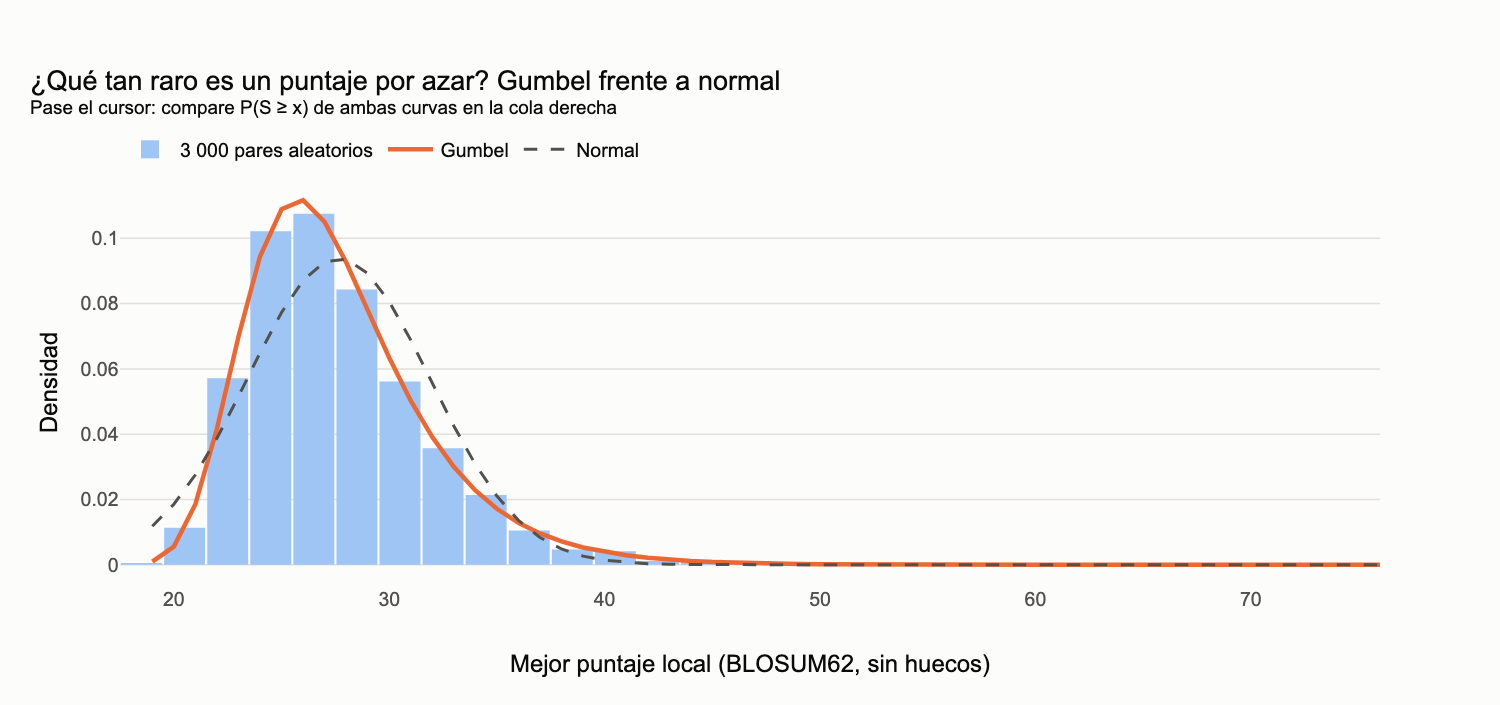

In [16]:
xs_plot = np.arange(int(null_scores.min()), int(null_scores.max()) + 25)
fig = go.Figure()
fig.add_histogram(x=null_scores, histnorm="probability density", xbins=dict(size=2), name="3 000 pares aleatorios",
                  marker_color=ec.SEQ_BLUE[2], hovertemplate="puntaje %{x}<br>densidad %{y:.3f}<extra></extra>")
fig.add_scatter(x=xs_plot, y=stats.gumbel_r.pdf(xs_plot, mu_g, beta_g), name="Gumbel", line=dict(color=ec.ORANGE, width=3),
                customdata=stats.gumbel_r.sf(xs_plot, mu_g, beta_g),
                hovertemplate="puntaje %{x}<br>Gumbel: P(S ≥ x) = %{customdata:.2e}<extra></extra>")
fig.add_scatter(x=xs_plot, y=stats.norm.pdf(xs_plot, mu_n, sd_n), name="Normal", line=dict(color=ec.INK_2, dash="dash"),
                customdata=stats.norm.sf(xs_plot, mu_n, sd_n),
                hovertemplate="puntaje %{x}<br>Normal: P(S ≥ x) = %{customdata:.2e}<extra></extra>")
fig.update_layout(title=dict(text="¿Qué tan raro es un puntaje por azar? Gumbel frente a normal"
                                  "<br><sup>Pase el cursor: compare P(S ≥ x) de ambas curvas en la cola derecha</sup>"),
                  xaxis_title="Mejor puntaje local (BLOSUM62, sin huecos)", yaxis_title="Densidad",
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=470, margin=dict(t=120),
                  bargap=0.05)
fig.show()

### ¿Y con huecos?

La fórmula de $\lambda$ sólo es exacta **sin huecos**. Con huecos no existe una fórmula cerrada, así que $\lambda$ y $K$
se estiman **por simulación**, exactamente como acabamos de hacer. NCBI publica sus valores precalculados; para
BLOSUM62 con costo de apertura 11 y extensión 1 son $\lambda \approx 0.267$ y $K \approx 0.041$. Estimémoslos
nosotros con Smith-Waterman completo (con huecos):

In [17]:
rng = np.random.default_rng(7)
n_gapped = 2000
q_rand = ["".join(rng.choice(list(AA), size=L_RAND, p=bg)) for _ in range(n_gapped)]
d_rand = ["".join(rng.choice(list(AA), size=L_RAND, p=bg)) for _ in range(n_gapped)]
gapped_scores = np.array([sw.score(a, b) for a, b in zip(q_rand, d_rand)])
mu_gg, beta_gg = stats.gumbel_r.fit(gapped_scores)
lambda_gap, K_gap = 1 / beta_gg, np.exp(mu_gg / beta_gg) / (L_RAND * L_RAND)
pd.DataFrame({"λ": [lambda_theory, lambda_emp, lambda_gap, 0.267],
              "K": [np.nan, K_emp, K_gap, 0.041]},
             index=["Sin huecos · fórmula", "Sin huecos · simulación", "Con huecos (11/1) · simulación",
                    "Con huecos (11/1) · valor de NCBI"]).round(3)

,λ,K
Sin huecos · fórmula,0.294,NaN
Sin huecos · simulación,0.304,0.113
Con huecos (11/1) · simulación,0.245,0.035
Con huecos (11/1) · valor de NCBI,0.267,0.041


> 🔎 **Qué observamos.** Con huecos, $\lambda$ baja (los huecos permiten alineamientos al azar algo más largos y
> puntajes más altos), y nuestra estimación queda cerca del valor publicado por NCBI. Las pequeñas diferencias vienen de
> la composición de aminoácidos (usamos la de *Mycoplasma*, muy rica en lisina e isoleucina) y del **efecto de borde**:
> con secuencias cortas, los alineamientos cerca de los extremos no tienen espacio para crecer.

## 9. Bit score, E-value y p-value

Los puntajes brutos dependen de la matriz: un 60 con BLOSUM62 no significa lo mismo que un 60 con PAM250. El
**bit score** los normaliza a una escala universal:

$$
S' \;=\; \frac{\lambda S - \ln K}{\ln 2}
\qquad\qquad
E \;=\; m\, n\, 2^{-S'}
\qquad\qquad
P \;=\; 1 - e^{-E}
$$

| Símbolo | Significado |
|---|---|
| $S$ | puntaje bruto (suma BLOSUM62) |
| $S'$ | **bit score**: puntaje en bits, independiente de la matriz y de $\lambda, K$ |
| $m$ | longitud de la consulta |
| $n$ | tamaño **total** de la base de datos (aminoácidos) |
| $E$ | **E-value**: cuántos alineamientos así de buenos esperaríamos **por azar** en esta búsqueda |
| $P$ | p-value: probabilidad de al menos uno así por azar (para $E < 0.01$, $P \approx E$) |

La segunda fórmula es la primera reescrita: sustituyendo $S'$ se recupera $E = K m n e^{-\lambda S}$. Cada **bit
adicional divide el E-value a la mitad**.

### Ejemplo a mano

RecA de *E. coli* ($m = 353$) contra el proteoma de *M. genitalium* ($n \approx 1.8 \times 10^{5}$), con un HSP de
puntaje bruto $S = 60$, usando $\lambda = 0.267$ y $K = 0.041$:

$$
S' = \frac{0.267 \times 60 - \ln 0.041}{\ln 2} = \frac{16.02 + 3.19}{0.693} \approx 27.7 \text{ bits}
$$

$$
E = 353 \times 1.8 \times 10^{5} \times 2^{-27.7} \approx \frac{6.4 \times 10^{7}}{2.2 \times 10^{8}} \approx 0.29
$$

Un E-value de 0.29 significa que en una búsqueda así esperaríamos **0.29 alineamientos al azar** con ese puntaje:
no es convincente. En cambio, con el **mismo** puntaje contra una base de datos $10^{5}$ veces más grande, el E-value
sería $\approx 29\,000$: completamente irrelevante. **El E-value depende del tamaño de la búsqueda.**

In [18]:
def bit_score(S_raw, lam, K):
    return (lam * S_raw - np.log(K)) / np.log(2)

def evalue(S_raw, m, n, lam, K):
    return m * n * 2.0 ** (-bit_score(S_raw, lam, K))

m_reca = len(queries["RECA"])
print(f"Bit score = {bit_score(60, 0.267, 0.041):.1f} bits · E = {evalue(60, m_reca, N_DB, 0.267, 0.041):.2f}")
for n in [N_DB, 1e8, 1e10]:
    print(f"  mismo S = 60 en una base de datos de {n:.1e} aa → E = {evalue(60, m_reca, n, 0.267, 0.041):.2e}")

Bit score = 27.7 bits · E = 0.29
  mismo S = 60 en una base de datos de 1.8e+05 aa → E = 2.86e-01
  mismo S = 60 en una base de datos de 1.0e+08 aa → E = 1.60e+02
  mismo S = 60 en una base de datos de 1.0e+10 aa → E = 1.60e+04


### Explorador interactivo: el E-value según el tamaño de la base de datos

Mueva el deslizador para cambiar el tamaño de la base de datos (desde un proteoma bacteriano hasta UniProtKB). La línea
punteada marca $E = 10^{-3}$, un umbral habitual para aceptar homología. Observe cuántos **bits** más necesita un
alineamiento para seguir siendo significativo cuando la base de datos crece.

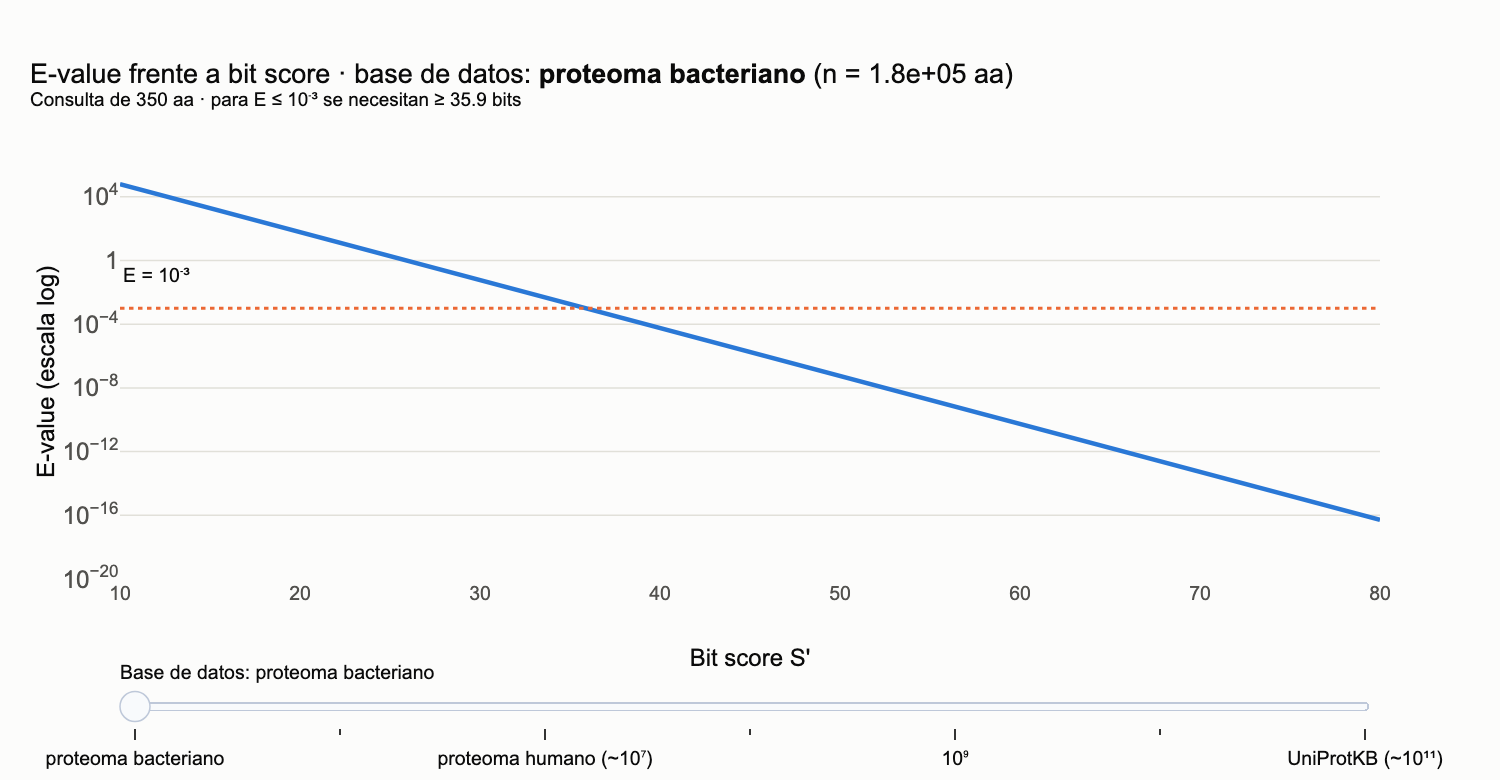

In [19]:
bits = np.linspace(10, 80, 300)
m_q = 350
db_sizes = [1.8e5, 1e6, 1e7, 1e8, 1e9, 1e10, 1e11]
labels = ["proteoma bacteriano", "10⁶", "proteoma humano (~10⁷)", "Swiss-Prot (~10⁸)", "10⁹", "10¹⁰", "UniProtKB (~10¹¹)"]
fig = go.Figure()
for k, (n, lab) in enumerate(zip(db_sizes, labels)):
    E = m_q * n * 2.0 ** (-bits)
    needed = np.log2(m_q * n / 1e-3)
    fig.add_scatter(x=bits, y=E, visible=(k == 0), line=dict(color=ec.BLUE, width=3), name=lab,
                    customdata=1 - np.exp(-E),
                    hovertemplate="bit score %{x:.1f}<br>E-value %{y:.2e}<br>p-value %{customdata:.2e}<extra></extra>")
steps = [dict(method="update", label=lab,
              args=[{"visible": [j == k for j in range(len(db_sizes))]},
                    {"title.text": f"E-value frente a bit score · base de datos: <b>{lab}</b> (n = {n:.1e} aa)"
                                   f"<br><sup>Consulta de {m_q} aa · para E ≤ 10⁻³ se necesitan "
                                   f"≥ {np.log2(m_q * n / 1e-3):.1f} bits</sup>"}])
         for k, (n, lab) in enumerate(zip(db_sizes, labels))]
fig.add_hline(y=1e-3, line_dash="dot", line_color=ec.ORANGE, annotation_text="E = 10⁻³", annotation_position="bottom left")
fig.update_layout(
    title=dict(text=f"E-value frente a bit score · base de datos: <b>{labels[0]}</b> (n = {db_sizes[0]:.1e} aa)"
                    f"<br><sup>Consulta de {m_q} aa · para E ≤ 10⁻³ se necesitan ≥ {np.log2(m_q * db_sizes[0] / 1e-3):.1f} bits</sup>"),
    yaxis=dict(type="log", title="E-value (escala log)", exponentformat="power", range=[-20, 6]),
    xaxis=dict(title="Bit score S'"),
    sliders=[dict(steps=steps, active=0, currentvalue=dict(prefix="Base de datos: "), pad=dict(t=50))],
    height=520, margin=dict(t=110), showlegend=False)
fig.show()

> 🔎 **Qué observamos.** Las curvas son rectas en escala logarítmica (cada bit divide $E$ entre 2). Al multiplicar la
> base de datos por 10, la recta se desplaza $\log_2 10 \approx 3.3$ bits a la derecha: para mantener la misma
> significancia, el alineamiento necesita 3.3 bits más.

### Los resultados del mini-BLAST, ahora con estadística

Convertimos los puntajes brutos del mini-BLAST (alineamientos **sin huecos**) usando los $\lambda$ y $K$ **sin huecos**
que estimamos por simulación.

In [20]:
hits_df["bits"] = bit_score(hits_df["raw_score"], lambda_emp, K_emp)
hits_df["evalue"] = [evalue(s, len(queries[q]), N_DB, lambda_emp, K_emp) for s, q in zip(hits_df["raw_score"], hits_df["query"])]
hits_df["significant"] = hits_df["evalue"] <= 1e-3
top = hits_df.sort_values("bits", ascending=False).groupby("query").head(3).sort_values(["query", "bits"], ascending=[True, False])
top[["query", "product", "raw_score", "bits", "evalue", "significant"]].style.format(
    {"bits": "{:.1f}", "evalue": "{:.1e}"}).hide(axis="index")

query,product,raw_score,bits,evalue,significant
CH60,chaperonin GroEL,594.000000,264.0,3.3e-72,True
CH60,30S ribosomal protein S5,57.000000,28.2,3.2e-01,False
CH60,ATP-dependent zinc metalloprotease FtsH,47.000000,23.8,6.8e+00,False
DNAK,molecular chaperone DnaK,612.000000,271.9,1.6e-74,True
DNAK,aspartate--tRNA ligase,58.000000,28.6,2.8e-01,False
DNAK,cation-translocating P-type ATPase,55.000000,27.3,6.9e-01,False
EFTU1,elongation factor Tu,1462.000000,645.2,4.1e-187,True
EFTU1,elongation factor G,96.000000,45.3,1.6e-06,True
EFTU1,translation initiation factor IF-2,86.000000,40.9,3.4e-05,True
GYRB,DNA topoisomerase (ATP-hydrolyzing) subunit B,579.000000,257.4,4.6e-70,True


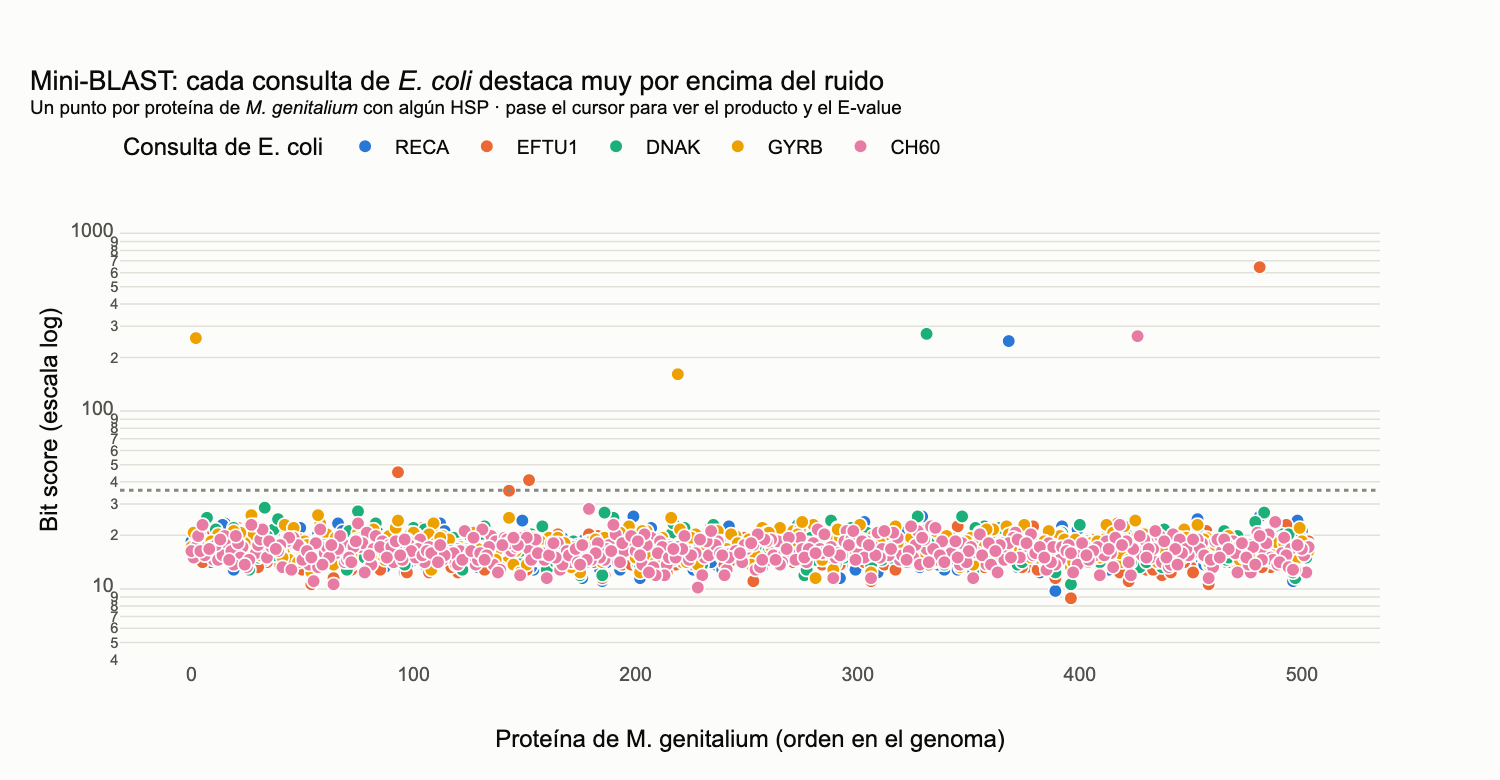

In [21]:
order = {tag: k for k, (tag, _, _) in enumerate(proteome)}
plot_df = hits_df.assign(protein_index=hits_df["subject"].map(order),
                         log10E=np.log10(hits_df["evalue"].clip(lower=1e-300)))
fig = px.scatter(plot_df, x="protein_index", y="bits", color="query",
                 color_discrete_sequence=ec.CATEGORICAL,
                 hover_data={"product": True, "subject": True, "raw_score": True, "evalue": ":.1e",
                             "protein_index": False, "log10E": False, "significant": True},
                 labels={"protein_index": "Proteína de M. genitalium (orden en el genoma)", "bits": "Bit score",
                         "query": "Consulta de E. coli", "significant": "E ≤ 10⁻³"})
thr_bits = np.log2(350 * N_DB / 1e-3)
fig.add_hline(y=thr_bits, line_dash="dot", line_color=ec.MUTED,
              annotation_text=f"≈ {thr_bits:.0f} bits → E = 10⁻³", annotation_position="top left")
fig.update_traces(marker=dict(size=9, line=dict(width=1, color=ec.SURFACE)))
fig.update_layout(title=dict(text="Mini-BLAST: cada consulta de <i>E. coli</i> destaca muy por encima del ruido"
                                  "<br><sup>Un punto por proteína de <i>M. genitalium</i> con algún HSP · pase el cursor para ver el producto y el E-value</sup>"),
                  yaxis=dict(type="log", range=[0.6, 3.3], title="Bit score (escala log)"), height=520,
                  margin=dict(t=120),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

> 🔎 **Qué observamos.** Cada consulta tiene **un** punto muy por encima de la línea de significancia (su ortólogo) y
> una nube de puntos por debajo (ruido). Algunas consultas tienen además un **segundo** resultado significativo: son
> **parálogos** o dominios compartidos. Por ejemplo, GyrB de *E. coli* encuentra tanto la girasa como la
> topoisomerasa IV de *Mycoplasma* (proteínas emparentadas), y EF-Tu encuentra también al factor de elongación G,
> que comparte el dominio de unión a GTP.

## 10. 🧪 Experimento: sensibilidad de BLAST frente a Smith-Waterman

¿Cuánta sensibilidad sacrificamos con las semillas? Tomemos proteínas del proteoma, hagámoslas "evolucionar" hasta
distintos niveles de identidad (sustituciones al azar y algunas inserciones/deleciones) y preguntemos a cada método si
detecta la relación con $E \le 10^{-3}$ (como si buscáramos contra todo el proteoma).

> 🤔 **Antes de ejecutar, prediga:** ¿a partir de qué porcentaje de identidad cree que ambos métodos empiezan a fallar?

In [22]:
rng = np.random.default_rng(11)
identities = [0.90, 0.70, 0.50, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15]
n_trials = 16
test_prots = [p[2][:300] for p in proteome if len(p[2]) >= 300]
records = []
for ident in identities:
    for t in range(n_trials):
        base = test_prots[rng.integers(len(test_prots))]
        homolog = evolve(base, ident, rng, indel_rate=0.01)
        # mini-BLAST (sin huecos) con su propio índice de una sola proteína
        hsps, _ = mini_blast(base, [("h", "", homolog)], build_index([("h", "", homolog)]))
        blast_E = evalue(hsps[0][0], len(base), N_DB, lambda_emp, K_emp) if hsps else np.inf
        sw_E = evalue(sw.score(base, homolog), len(base), N_DB, lambda_gap, K_gap)
        records.append({"identity": ident, "mini_blast": blast_E <= 1e-3, "smith_waterman": sw_E <= 1e-3})
sens = pd.DataFrame(records).groupby("identity")[["mini_blast", "smith_waterman"]].mean().sort_index(ascending=False)
sens.style.format("{:.0%}")

,mini_blast,smith_waterman
identity,,
0.900000,100%,100%
0.700000,100%,100%
0.500000,100%,100%
0.400000,100%,100%
0.350000,100%,100%
0.300000,75%,100%
0.250000,44%,94%
0.200000,25%,38%
0.150000,0%,0%


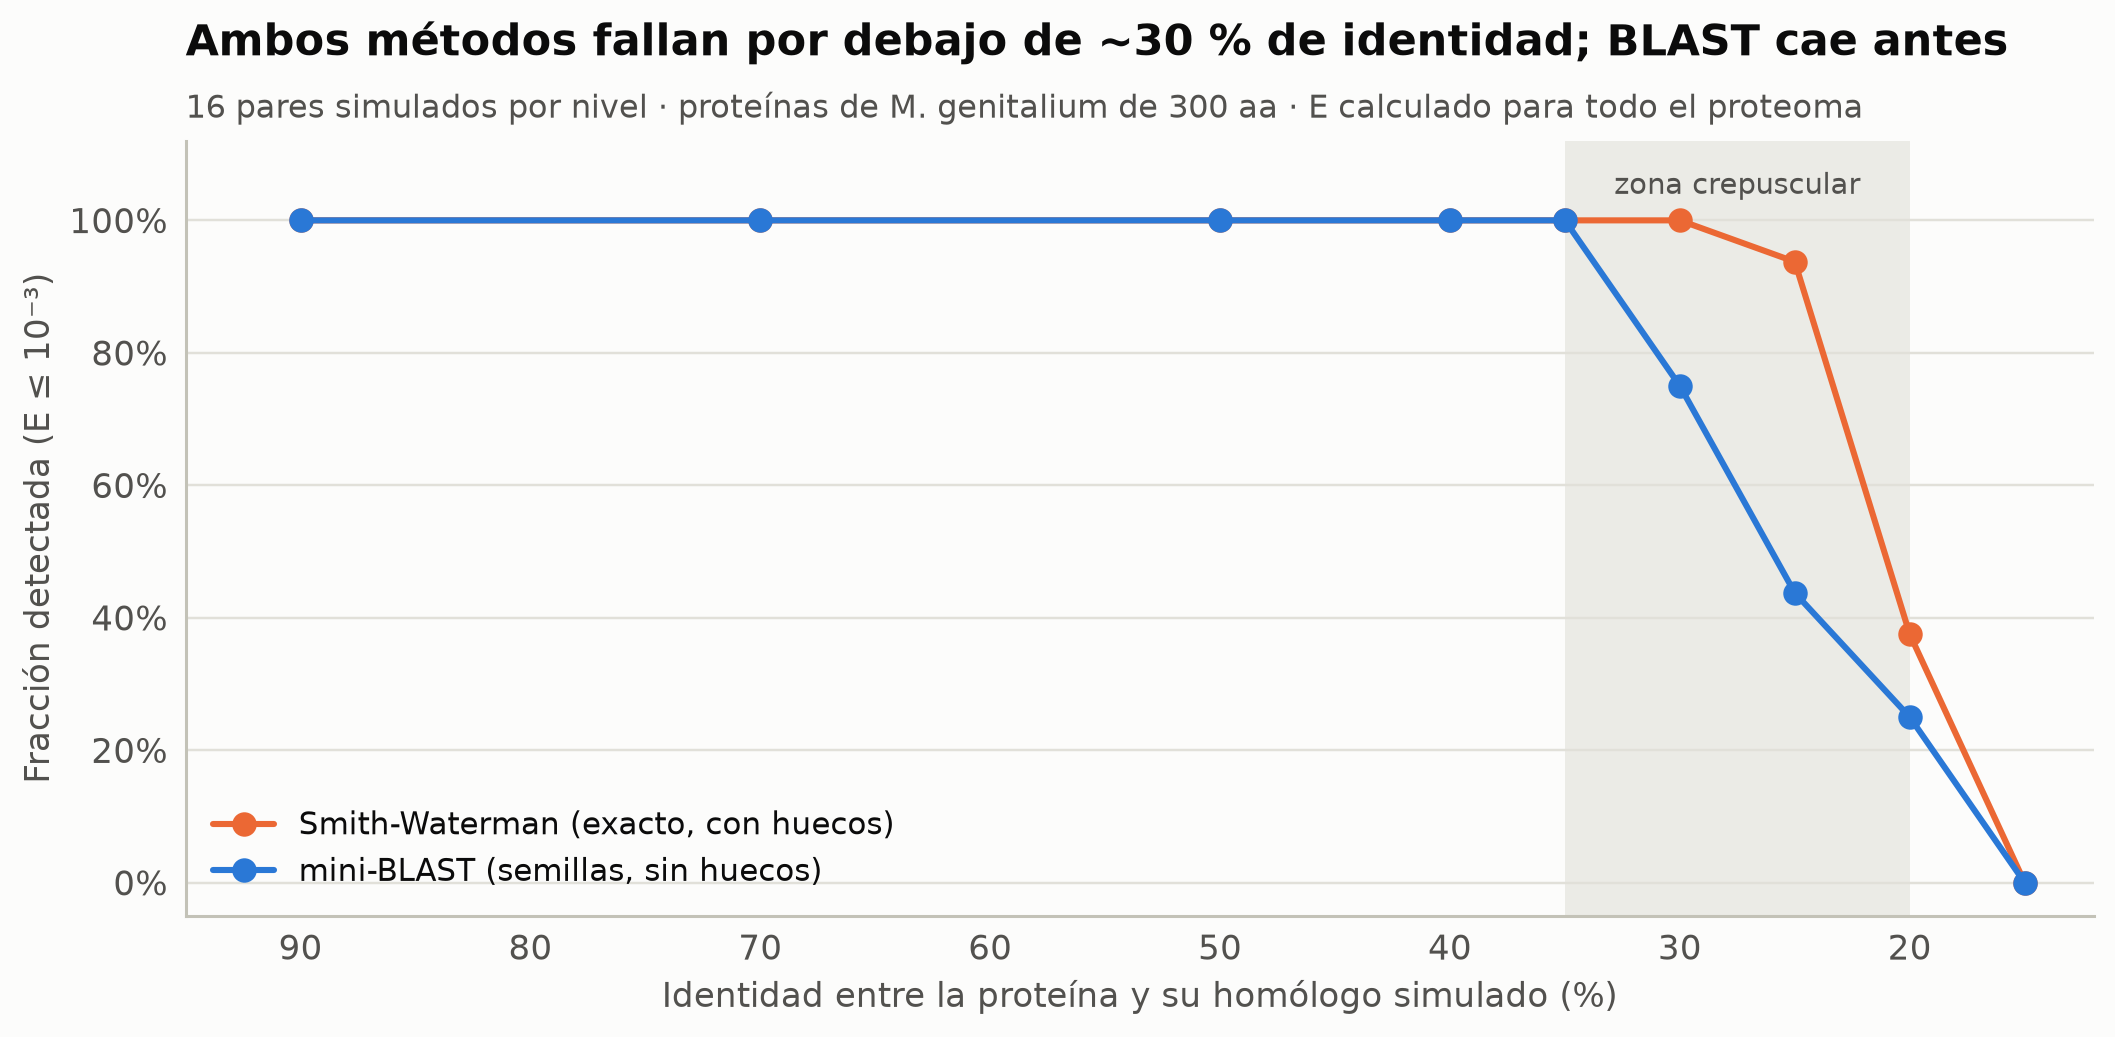

In [23]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
x_id = sens.index * 100
ax.axvspan(20, 35, color=ec.GRID, alpha=0.6, lw=0)
ax.text(27.5, 1.04, "zona crepuscular", ha="center", fontsize=9.5, color=ec.INK_2)
ax.plot(x_id, sens["smith_waterman"], "o-", color=ec.ORANGE, label="Smith-Waterman (exacto, con huecos)")
ax.plot(x_id, sens["mini_blast"], "o-", color=ec.BLUE, label="mini-BLAST (semillas, sin huecos)")
ax.legend(loc="lower left")
ax.set_xlim(95, 12)                     # la identidad decrece hacia la derecha: el tiempo evolutivo avanza
ax.set_ylim(-0.05, 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Identidad entre la proteína y su homólogo simulado (%)")
ax.set_ylabel("Fracción detectada (E ≤ 10⁻³)")
ec.title(ax, "Ambos métodos fallan por debajo de ~30 % de identidad; BLAST cae antes",
         f"{n_trials} pares simulados por nivel · proteínas de M. genitalium de 300 aa · E calculado para todo el proteoma")
plt.show()

> 🔎 **Qué observamos.** Por encima de ~40 % de identidad ambos métodos detectan prácticamente todo. En la **zona
> crepuscular** (20–35 % de identidad) la detección se desploma: las secuencias han cambiado tanto que su parecido se
> confunde con el azar. El mini-BLAST cae un poco **antes** que Smith-Waterman: a veces no hay dos semillas en la
> misma diagonal, o los indels cortan el tramo sin huecos. Es el precio de la velocidad.
>
> Para ir más allá de la zona crepuscular se usan métodos basados en **perfiles** (PSI-BLAST, HMMER), que veremos en
> el Módulo 4.

✅ **Compruebe su comprensión.** Si duplicamos el tamaño de la base de datos, ¿se desplazarían estas curvas? ¿Hacia
dónde? (Pista: el umbral de E exige 1 bit más.)

## 11. 🧪 BLAST+ de verdad (en Colab)

Ahora usemos el programa real, **BLAST+** de NCBI (Camacho *et al.*, 2009). Construimos una base de datos con el
proteoma de *M. genitalium* (`makeblastdb`) y buscamos las cinco proteínas de *E. coli* con `blastp`. La tabla de
salida (`-outfmt 6`) ya la conoce de la Lección 0.2.

In [24]:
if shutil.which("blastp") is None and IN_COLAB:
    !apt-get -qq install -y ncbi-blast+ > /dev/null
HAS_BLAST = shutil.which("blastp") is not None
print("BLAST+ disponible:", HAS_BLAST)
if HAS_BLAST:
    print(subprocess.run(["blastp", "-version"], capture_output=True, text=True).stdout.splitlines()[0])
else:
    print("⚠️ Ejecute este notebook en Colab para usar BLAST+ (aquí se omite esta sección).")

BLAST+ disponible: False
⚠️ Ejecute este notebook en Colab para usar BLAST+ (aquí se omite esta sección).


In [25]:
if HAS_BLAST:
    with open("mgen_proteome.fasta", "w") as fh:
        for tag, prod, seq in proteome:
            fh.write(f">{tag} {prod}\n{seq}\n")
    with open("ecoli_queries.fasta", "w") as fh:
        for name, seq in queries.items():
            fh.write(f">{name}\n{seq}\n")
    subprocess.run(["makeblastdb", "-in", "mgen_proteome.fasta", "-dbtype", "prot", "-out", "mgen_db"],
                   check=True, capture_output=True)
    cols = "qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore stitle"
    subprocess.run(["blastp", "-query", "ecoli_queries.fasta", "-db", "mgen_db", "-outfmt", f"6 {cols}",
                    "-evalue", "10", "-max_target_seqs", "50", "-out", "blast_hits.tsv"], check=True)
    blast = pd.read_csv("blast_hits.tsv", sep="\t", names=cols.split())
    display(blast.sort_values("bitscore", ascending=False).groupby("qseqid").head(2)
                 [["qseqid", "stitle", "pident", "length", "evalue", "bitscore"]].reset_index(drop=True))

In [26]:
if HAS_BLAST:
    fig, ax = plt.subplots(figsize=(10, 4.8))
    for k, (name, sub) in enumerate(blast.groupby("qseqid")):
        ax.scatter(sub["bitscore"], -np.log10(sub["evalue"].clip(lower=1e-180)), s=40,
                   color=ec.CATEGORICAL[k], edgecolor=ec.SURFACE, linewidth=1.5, label=name, zorder=3)
    ax.axhline(3, color=ec.ORANGE, lw=1.2)
    ax.text(ax.get_xlim()[1], 3, "  E = 10⁻³", va="bottom", ha="right", color=ec.INK_2, fontsize=9.5)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlabel("Bit score (escala log)"); ax.set_ylabel("−log₁₀(E-value)")
    ax.grid(True, axis="both")
    ax.legend(title="Consulta", loc="upper left", fontsize=9.5)
    ec.title(ax, "BLAST+ confirma los ortólogos: bit score y E-value van de la mano",
             "blastp de 5 proteínas de E. coli contra el proteoma de M. genitalium · un punto por HSP")
    plt.show()

    # ¿Coinciden el mini-BLAST y BLAST+ en el mejor resultado de cada consulta?
    best_real = blast.sort_values("bitscore", ascending=False).groupby("qseqid").head(1).set_index("qseqid")
    best_mini = hits_df.sort_values("bits", ascending=False).groupby("query").head(1).set_index("query")
    compare = pd.DataFrame({"BLAST+": best_real["sseqid"], "mini-BLAST": best_mini["subject"].reindex(best_real.index)})
    compare["¿coinciden?"] = compare["BLAST+"] == compare["mini-BLAST"]
    display(compare)

> 🔎 **Qué observamos (en Colab).** BLAST+ encuentra los mismos ortólogos que nuestro mini-BLAST, con E-values
> astronómicamente pequeños (del orden de $10^{-60}$ o menos). Sus bit scores son distintos a los nuestros porque BLAST+
> hace extensión **con huecos**, ajusta la composición de aminoácidos (*composition-based statistics*) y corrige
> los tamaños efectivos por el efecto de borde.

### Opcional: BLAST remoto en los servidores de NCBI

Biopython puede enviar una búsqueda a los servidores de NCBI contra bases de datos enormes (como `nr`). Tarda desde
segundos hasta varios minutos y NCBI limita su uso, así que no lo ejecutamos automáticamente:

```python
from Bio.Blast import NCBIWWW, NCBIXML
handle = NCBIWWW.qblast("blastp", "swissprot", queries["RECA"], hitlist_size=10)
record = NCBIXML.read(handle)
for aln in record.alignments[:5]:
    print(aln.title[:80], aln.hsps[0].expect)
```

## ✍️ Ejercicios

**Ejercicio 1 — E-value a mano.** Un alineamiento tiene un bit score de 50 bits; la consulta mide 250 aminoácidos y la
base de datos $10^{9}$. Calcule el E-value con $E = m\,n\,2^{-S'}$. ¿Lo aceptaría como homólogo?

**Ejercicio 2 — $\lambda$ para BLASTN.** El programa BLASTN usa por defecto (en su modo clásico) +1 para coincidencia y
−3 para diferencia. Con bases equiprobables, resuelva numéricamente
$\tfrac14 e^{\lambda} + \tfrac34 e^{-3\lambda} = 1$. ¿Por qué $\lambda$ es mayor que con +1/−1?

**Ejercicio 3 — La perilla $T$.** Repita el mini-BLAST de RecA contra el proteoma con $T = 11, 13, 15$. Anote el número
de semillas, el tiempo y si el ortólogo sigue siendo el primer resultado. ¿Qué pasaría con homólogos más lejanos?

**Ejercicio 4 — Base de datos el doble de grande.** Si la base de datos se duplica, ¿qué le pasa al E-value de un mismo
alineamiento? ¿Cuántos bits adicionales necesita para recuperar el mismo E-value? Demuéstrelo con la fórmula.

In [27]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
E1 = 250 * 1e9 * 2.0 ** (-50)
print(f"E = {E1:.2e}  → se esperan {E1:.4f} alineamientos al azar así: sí es significativo (E < 10⁻³).")

E = 2.22e-04  → se esperan 0.0002 alineamientos al azar así: sí es significativo (E < 10⁻³).


In [28]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
M13 = np.where(np.eye(4) == 1, 1, -3)
lam13 = solve_lambda(np.full(4, .25), np.full(4, .25), M13)
print(f"lambda (+1/-3) = {lam13:.3f}   vs   lambda (+1/-1) = {np.log(3):.3f}")
print("Con -3 las diferencias castigan más: los puntajes altos al azar son más raros y la cola cae más rápido (λ mayor).")

lambda (+1/-3) = 1.374   vs   lambda (+1/-1) = 1.099
Con -3 las diferencias castigan más: los puntajes altos al azar son más raros y la cola cae más rápido (λ mayor).


In [29]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
for T in [11, 13, 15]:
    t0 = time.perf_counter()
    hsps, counts = mini_blast(queries["RECA"], proteome, index, T=T)
    best_sid = max(hsps, key=lambda s: hsps[s][0])
    print(f"T = {T}: {counts['semillas']:>7,} semillas · {time.perf_counter() - t0:.2f} s · "
          f"mejor resultado: {proteome[best_sid][1]} (S = {hsps[best_sid][0]})")
print("Con T alto hay menos semillas y es más rápido; los homólogos lejanos (pocas palabras parecidas) se pierden primero.")

T = 11: 115,316 semillas · 1.07 s · mejor resultado: recombinase RecA (S = 557.0)
T = 13:  33,245 semillas · 0.16 s · mejor resultado: recombinase RecA (S = 557.0)
T = 15:   8,280 semillas · 0.02 s · mejor resultado: recombinase RecA (S = 557.0)
Con T alto hay menos semillas y es más rápido; los homólogos lejanos (pocas palabras parecidas) se pierden primero.


In [30]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
# E = m n 2^(-S')  →  con 2n, E se duplica; para compensar: 2^(-S'') * 2n = 2^(-S') * n  →  S'' = S' + 1
S1 = 40
print(f"n:  E = {350 * 1e8 * 2.0 ** -S1:.3e}")
print(f"2n: E = {350 * 2e8 * 2.0 ** -S1:.3e}  (el doble)")
print(f"2n con {S1 + 1} bits: E = {350 * 2e8 * 2.0 ** -(S1 + 1):.3e}  (recuperado con 1 bit más)")

n:  E = 3.183e-02
2n: E = 6.366e-02  (el doble)
2n con 41 bits: E = 3.183e-02  (recuperado con 1 bit más)


## 📌 Resumen

* Smith-Waterman contra una base de datos cuesta $m \cdot N$ operaciones: impracticable a la escala de UniProt.
* **BLAST** busca primero **palabras vecinas** (umbral $T$), exige **dos impactos** en la misma diagonal y **extiende**
  con la regla **X-drop**; sacrifica un poco de sensibilidad a cambio de muchísima velocidad.
* Los puntajes de alineamientos locales aleatorios siguen una **distribución de Gumbel** (valores extremos), con una
  cola exponencial de pendiente $\lambda$; usar la normal subestima el azar.
* $\lambda$ resuelve $\sum p_a p_b e^{\lambda s(a,b)} = 1$ (sin huecos); con huecos, $\lambda$ y $K$ se estiman por
  simulación.
* **Bit score** $S' = (\lambda S - \ln K)/\ln 2$; **E-value** $E = m\,n\,2^{-S'}$: el número de aciertos esperados por
  azar. El mismo alineamiento es menos significativo en una base de datos más grande.
* Por debajo de ~30 % de identidad (zona crepuscular) la homología se vuelve difícil de detectar con alineamientos de
  pares; allí entran los perfiles (Módulo 4).

**Próximo módulo (4):** alineamiento múltiple, motivos y perfiles — cuando comparar de a dos no alcanza.

## 📚 Para profundizar

* Altschul, S. F., Gish, W., Miller, W., Myers, E. W. & Lipman, D. J. (1990). Basic local alignment search tool.
  *Journal of Molecular Biology* 215(3): 403–410.
* Karlin, S. & Altschul, S. F. (1990). Methods for assessing the statistical significance of molecular sequence
  features by using general scoring schemes. *PNAS* 87(6): 2264–2268.
* Altschul, S. F. *et al.* (1997). Gapped BLAST and PSI-BLAST: a new generation of protein database search programs.
  *Nucleic Acids Research* 25(17): 3389–3402.
* Camacho, C. *et al.* (2009). BLAST+: architecture and applications. *BMC Bioinformatics* 10: 421.
* Rost, B. (1999). Twilight zone of protein sequence alignments. *Protein Engineering* 12(2): 85–94.

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)